In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from matplotlib.patheffects import withStroke
# import geopandas as gpd
from netCDF4 import Dataset
import os
# import cv2
# import datetime
# import numba
import pickle
# from shapely.geometry import Point, Polygon
# import inspect
import glob
# import h5py
import scipy
from matplotlib.path import Path

import track

# Extract META Data

分配至少4核避免内存不足

In [2]:
lonmin = 140 - 2.5
lonmax = 180 + 2.5
latmin = 28  - 2.5
latmax = 40  + 2.5

track.lonmin = lonmin
track.lonmax = lonmax
track.latmin = latmin
track.latmax = latmax

In [3]:
# path = '/Users/jjijack/Documents/Visual Studio Code/Python/EddyNet/META-Data-Converter/'
# path = '../META3.1/'
path = '../META3.2_DT_allsat'

ACS, ACL, CS, CL = track.load_meta_data(path)

In [4]:
track.process_and_save(ACS, 'acs.pkl')
track.process_and_save(ACL, 'acl.pkl')
track.process_and_save(CS, 'cs.pkl')
track.process_and_save(CL, 'cl.pkl')

ACS count: 8613
ACL count: 15464
CS count: 9294
CL count: 17705


# Extract Mat Data

In [2]:
for yr in range(2002,2024):
    track.convert_mat_to_parquet(year=yr)

Starting to process data for the year: 2002
Generated paths for .mat files:
  - ./Argo_addFloat/Argo2002_1.mat
  - ./Argo_addFloat/Argo2002_2.mat
  - ./Argo_addFloat/Argo2002_3.mat
  - ./Argo_addFloat/Argo2002_4.mat
  - ./Argo_addFloat/Argo2002_5.mat
  - ./Argo_addFloat/Argo2002_6.mat
  - ./Argo_addFloat/Argo2002_7.mat
  - ./Argo_addFloat/Argo2002_8.mat
  - ./Argo_addFloat/Argo2002_9.mat
  - ./Argo_addFloat/Argo2002_10.mat
  - ./Argo_addFloat/Argo2002_11.mat
  - ./Argo_addFloat/Argo2002_12.mat

Reading .mat files...
Successfully read and processed ./Argo_addFloat/Argo2002_9.mat
Successfully read and processed ./Argo_addFloat/Argo2002_10.mat
Successfully read and processed ./Argo_addFloat/Argo2002_11.mat
Successfully read and processed ./Argo_addFloat/Argo2002_12.mat

Concatenating all loaded data...

Success! All data for 2002 successfully saved to:
  -> ./Argo_data/Argo2002.parquet
Starting to process data for the year: 2003
Generated paths for .mat files:
  - ./Argo_addFloat/Argo2003

# Read Mat Data

In [2]:
argo_data = pd.read_parquet("./Argo_data/Argo2014.parquet")
print(np.unique(argo_data["Datasets_number"])) #datasets_number==1 means Argo data
argo_data = argo_data.drop(columns=['Salinity_psu', 'Oxygen_flag', 'Oxygen_flag2', 'Datasets_number', 'Cycle_number', 'Float_serial_no'])

[1.]


In [3]:
argo_data

,Year,Month,Day,Longitude,Latitude,Depth_m,DO_mol_kg,Temperature_degC,Profile_number,Platform_number
0,2014.0,1.0,1.0,28.659855,42.344217,0.500000,308.346802,9.475,34383.0,7900591.0
1,2014.0,1.0,1.0,28.659855,42.344217,1.500000,308.055176,9.477,34383.0,7900591.0
2,2014.0,1.0,1.0,28.659855,42.344217,2.600000,307.280914,9.477,34383.0,7900591.0
3,2014.0,1.0,1.0,28.659855,42.344217,3.700000,306.721008,9.476,34383.0,7900591.0
4,2014.0,1.0,1.0,28.659855,42.344217,4.900000,305.976624,9.482,34383.0,7900591.0
...,...,...,...,...,...,...,...,...,...,...
2907959,2014.0,12.0,29.0,4.161000,70.146000,1751.430054,312.416504,-0.579,230331.0,6902550.0
2907960,2014.0,12.0,29.0,4.161000,70.146000,1801.670044,311.425629,-0.600,230331.0,6902550.0
2907961,2014.0,12.0,29.0,4.161000,70.146000,1851.569946,310.973022,-0.617,230331.0,6902550.0
2907962,2014.0,12.0,29.0,4.161000,70.146000,1901.339966,309.940399,-0.637,230331.0,6902550.0


# Plot Monthly Trajectories

In [2]:
with open('acs.pkl', 'rb') as f:
    acs = pickle.load(f)

with open('acl.pkl', 'rb') as f:
    acl = pickle.load(f)

with open('cs.pkl', 'rb') as f:
    cs = pickle.load(f)

with open('cl.pkl', 'rb') as f:
    cl = pickle.load(f)

In [3]:
eddy_datasets = {
    'ACS': acs,
    'ACL': acl,
    'CS': cs,
    'CL': cl
}

### Display

In [4]:
start_date = '2014-04-01'
end_date = '2014-04-30'

/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:2558: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


Preprocessing Argo data for the given time range...
Running parallel processing for 51076 tasks across 4 cores...
Plotting results...


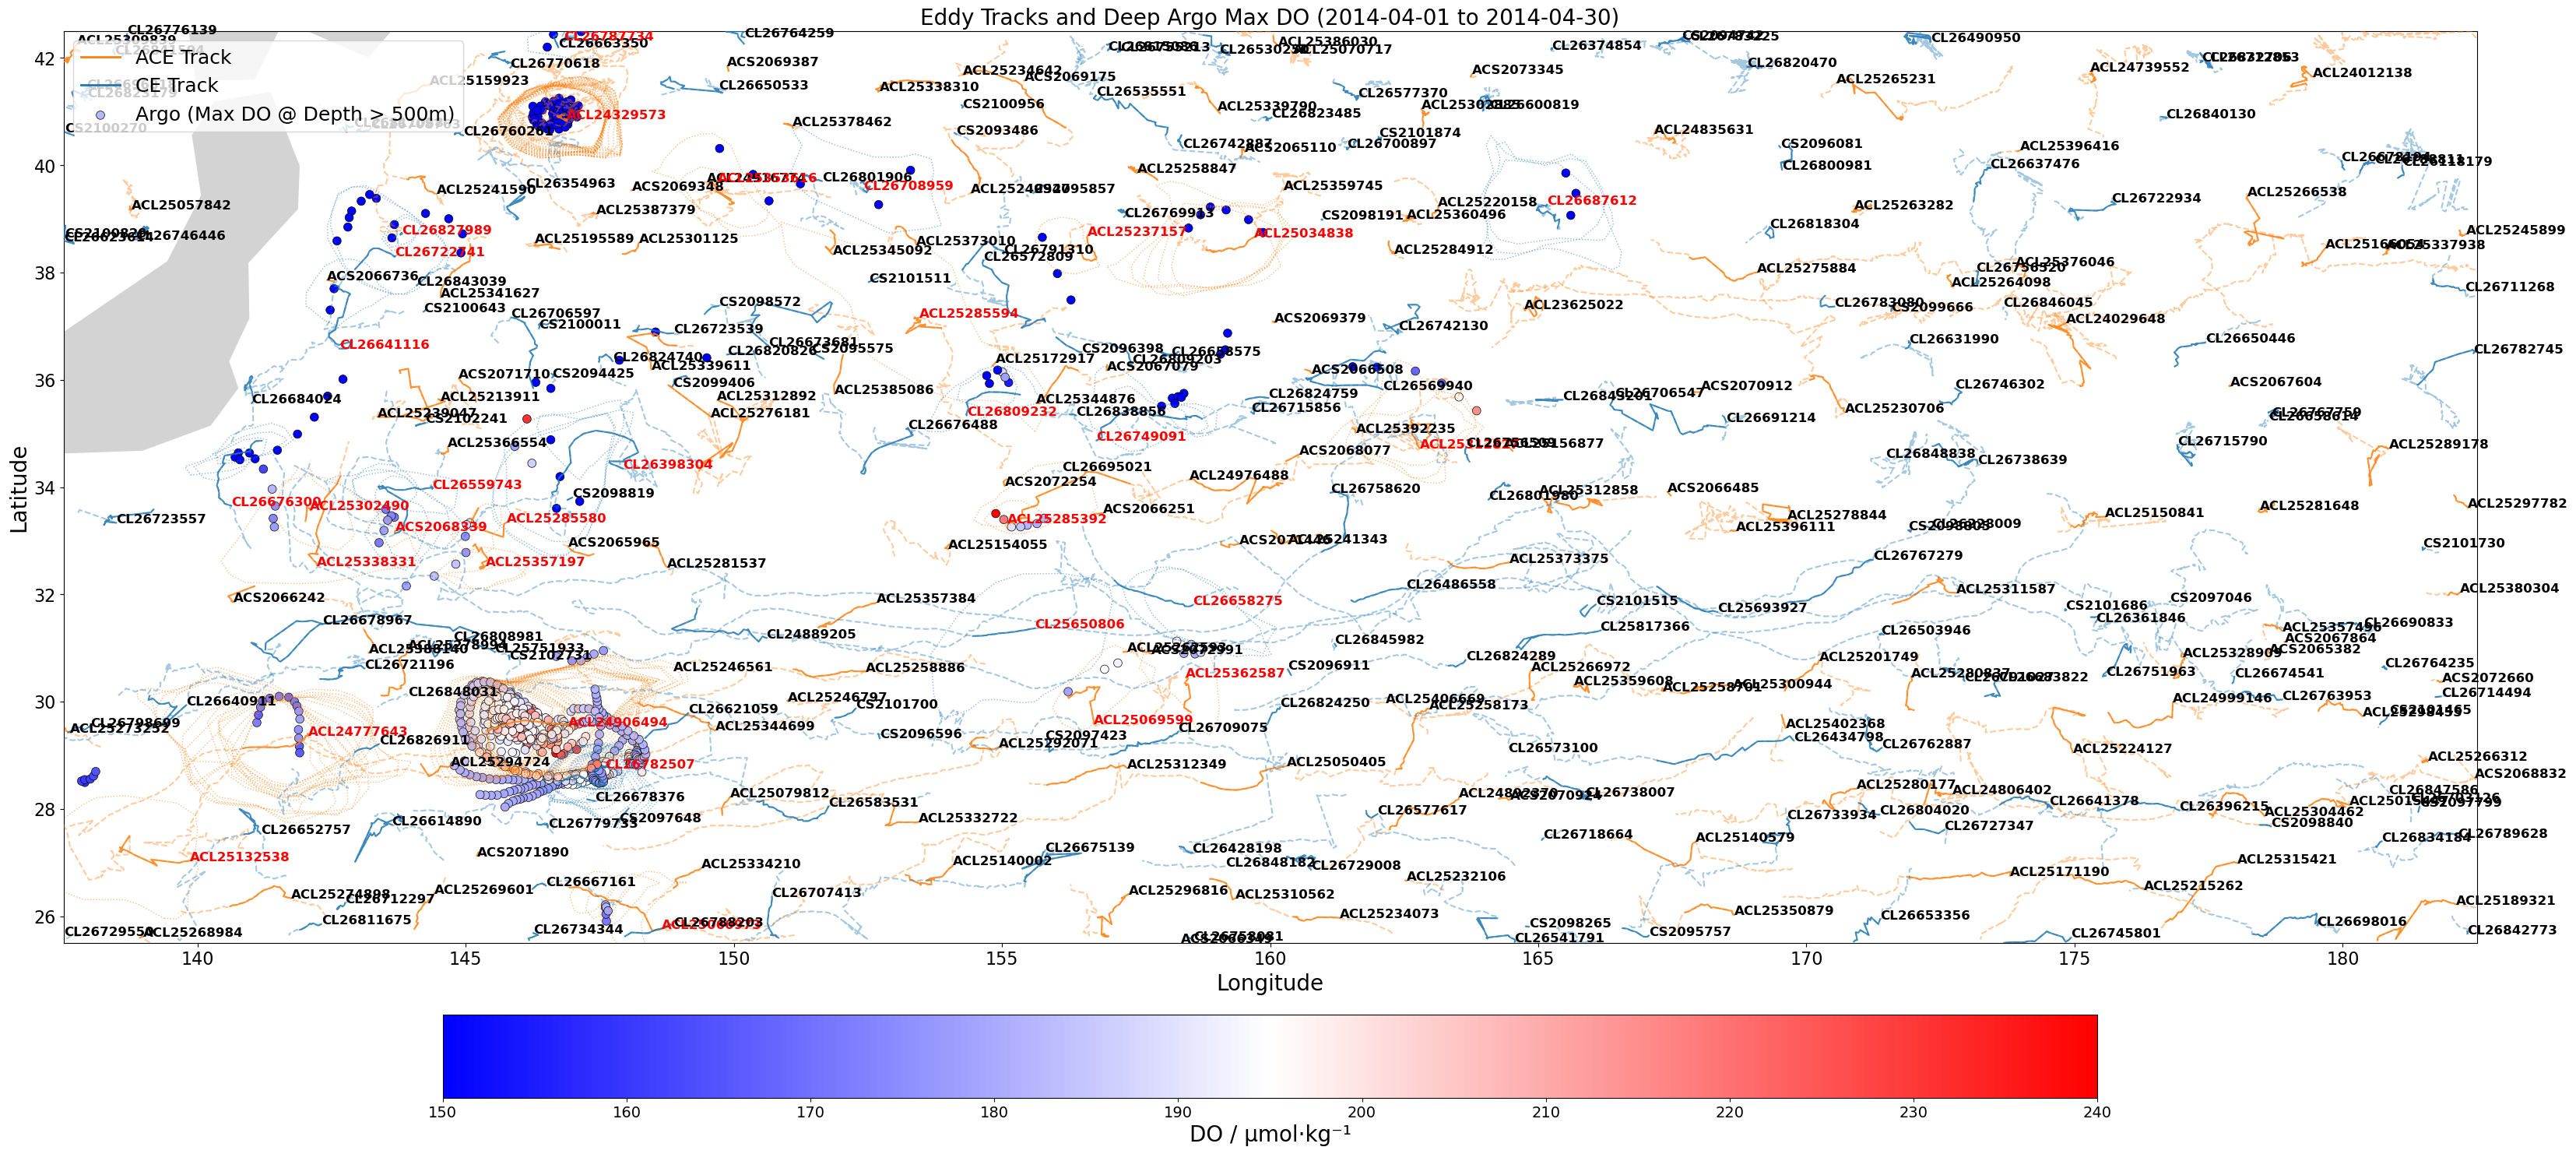

In [ ]:
track.plot_all_tracks_in_range(
    datasets=eddy_datasets, 
    start_date_str=start_date, 
    end_date_str=end_date, 
    num_workers= 4,
    chunk_size= 100,
    save_fig=False, 
    show_fig=True
)

### Output

In [ ]:
TOTAL_OUTER_PROCESSES = 4  # 总数据按时间切分的段数
WORKERS_PER_PROCESS = 4    # 每段数据使用的进程数
INNER_CHUNK_SIZE = 100      # 内部绘图函数使用的chunksize

In [7]:
track.run_nested_parallel_batch(
    start_date_str='2002-09-01',
    end_date_str='2023-04-30',
    eddy_datasets=eddy_datasets,
    total_outer_processes=TOTAL_OUTER_PROCESSES,
    workers_per_process=WORKERS_PER_PROCESS,
    inner_chunk_size=INNER_CHUNK_SIZE
)

      Nested Parallel Batch Processing      
Strategy: 4 supervisor processes, each with 4 workers.
Total cores to be utilized: 16

--- Starting Supervisor Processes ---
[Supervisor PID: 2349381] Started processing time chunk: 2002-09-01 to 2007-10-01
[Supervisor PID: 2349381] Loading Argo data for year 2002...
Attempting to load Argo data from: ./Argo_data/Argo2002.parquet
Argo data loaded successfully.
[Supervisor PID: 2349381] (1/62) Submitting plot job for 2002-09...
Preprocessing Argo data for the given time range...
Running parallel processing for 51076 tasks across 4 cores...
Plotting results...
Figure saved to: plot_all_tracks_in_range/All_Tracks_2002-09-01_to_2002-09-30.png
[Supervisor PID: 2349381] (2/62) Submitting plot job for 2002-10...
Preprocessing Argo data for the given time range...
Running parallel processing for 51076 tasks across 4 cores...


/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:2558: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:2558: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


[Supervisor PID: 2357305] Started processing time chunk: 2007-11-01 to 2012-12-01
[Supervisor PID: 2357305] Loading Argo data for year 2007...
Attempting to load Argo data from: ./Argo_data/Argo2007.parquet
Argo data loaded successfully.
[Supervisor PID: 2357305] (1/62) Submitting plot job for 2007-11...
Preprocessing Argo data for the given time range...
Running parallel processing for 51076 tasks across 4 cores...
Plotting results...
Figure saved to: plot_all_tracks_in_range/All_Tracks_2002-10-01_to_2002-10-31.png
[Supervisor PID: 2349381] (3/62) Submitting plot job for 2002-11...
Preprocessing Argo data for the given time range...
Running parallel processing for 51076 tasks across 4 cores...
Plotting results...
Figure saved to: plot_all_tracks_in_range/All_Tracks_2007-11-01_to_2007-11-30.png
[Supervisor PID: 2357305] (2/62) Submitting plot job for 2007-12...
Preprocessing Argo data for the given time range...
Running parallel processing for 51076 tasks across 4 cores...


/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:2558: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:2558: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:2558: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gp

[Supervisor PID: 2365071] Started processing time chunk: 2013-01-01 to 2018-02-01
[Supervisor PID: 2365071] Loading Argo data for year 2013...
Attempting to load Argo data from: ./Argo_data/Argo2013.parquet
Argo data loaded successfully.
[Supervisor PID: 2365071] (1/62) Submitting plot job for 2013-01...
Preprocessing Argo data for the given time range...
Running parallel processing for 51076 tasks across 4 cores...
Plotting results...
Figure saved to: plot_all_tracks_in_range/All_Tracks_2002-11-01_to_2002-11-30.png
[Supervisor PID: 2349381] (4/62) Submitting plot job for 2002-12...
Preprocessing Argo data for the given time range...
Running parallel processing for 51076 tasks across 4 cores...
Plotting results...
Figure saved to: plot_all_tracks_in_range/All_Tracks_2007-12-01_to_2007-12-31.png
[Supervisor PID: 2357305] Loading Argo data for year 2008...
Attempting to load Argo data from: ./Argo_data/Argo2008.parquet
Argo data loaded successfully.
[Supervisor PID: 2357305] (3/62) Submi

...

Running parallel processing for 51076 tasks across 4 cores...
Plotting results...
Figure saved to: plot_all_tracks_in_range/All_Tracks_2012-12-01_to_2012-12-31.png
[Supervisor PID: 2357305] Finished processing its entire time chunk.
Plotting results...
[Supervisor PID: 2371427] (62/62) Submitting plot job for 2023-04...
Plotting results...


/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:2558: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


Preprocessing Argo data for the given time range...
Running parallel processing for 51076 tasks across 4 cores...
Figure saved to: plot_all_tracks_in_range/All_Tracks_2018-01-01_to_2018-01-31.png
[Supervisor PID: 2365071] (62/62) Submitting plot job for 2018-02...


/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:2558: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


Preprocessing Argo data for the given time range...
Running parallel processing for 51076 tasks across 4 cores...
Plotting results...
[Supervisor PID: 2371427] Finished processing its entire time chunk.
Plotting results...
Figure saved to: plot_all_tracks_in_range/All_Tracks_2018-02-01_to_2018-02-28.png
[Supervisor PID: 2365071] Finished processing its entire time chunk.

--- All Supervisor Processes Have Finished ---
Total execution time: 0.95 hours.


# Plot Argo Hotspots

--- Starting Deep Argo DO Hotspot Analysis ---
Loading all Argo data from 2002 to 2023...
Processing year: 2002...
Attempting to load Argo data from: ./Argo_data/Argo2002.parquet
Argo data loaded successfully.
Processing year: 2003...
Attempting to load Argo data from: ./Argo_data/Argo2003.parquet
Argo data loaded successfully.
Processing year: 2004...
Attempting to load Argo data from: ./Argo_data/Argo2004.parquet
Argo data loaded successfully.
Processing year: 2005...
Attempting to load Argo data from: ./Argo_data/Argo2005.parquet
Argo data loaded successfully.
Processing year: 2006...
Attempting to load Argo data from: ./Argo_data/Argo2006.parquet
Argo data loaded successfully.
Processing year: 2007...
Attempting to load Argo data from: ./Argo_data/Argo2007.parquet
Argo data loaded successfully.
Processing year: 2008...
Attempting to load Argo data from: ./Argo_data/Argo2008.parquet
Argo data loaded successfully.
Processing year: 2009...
Attempting to load Argo data from: ./Argo_dat

/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:2828: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


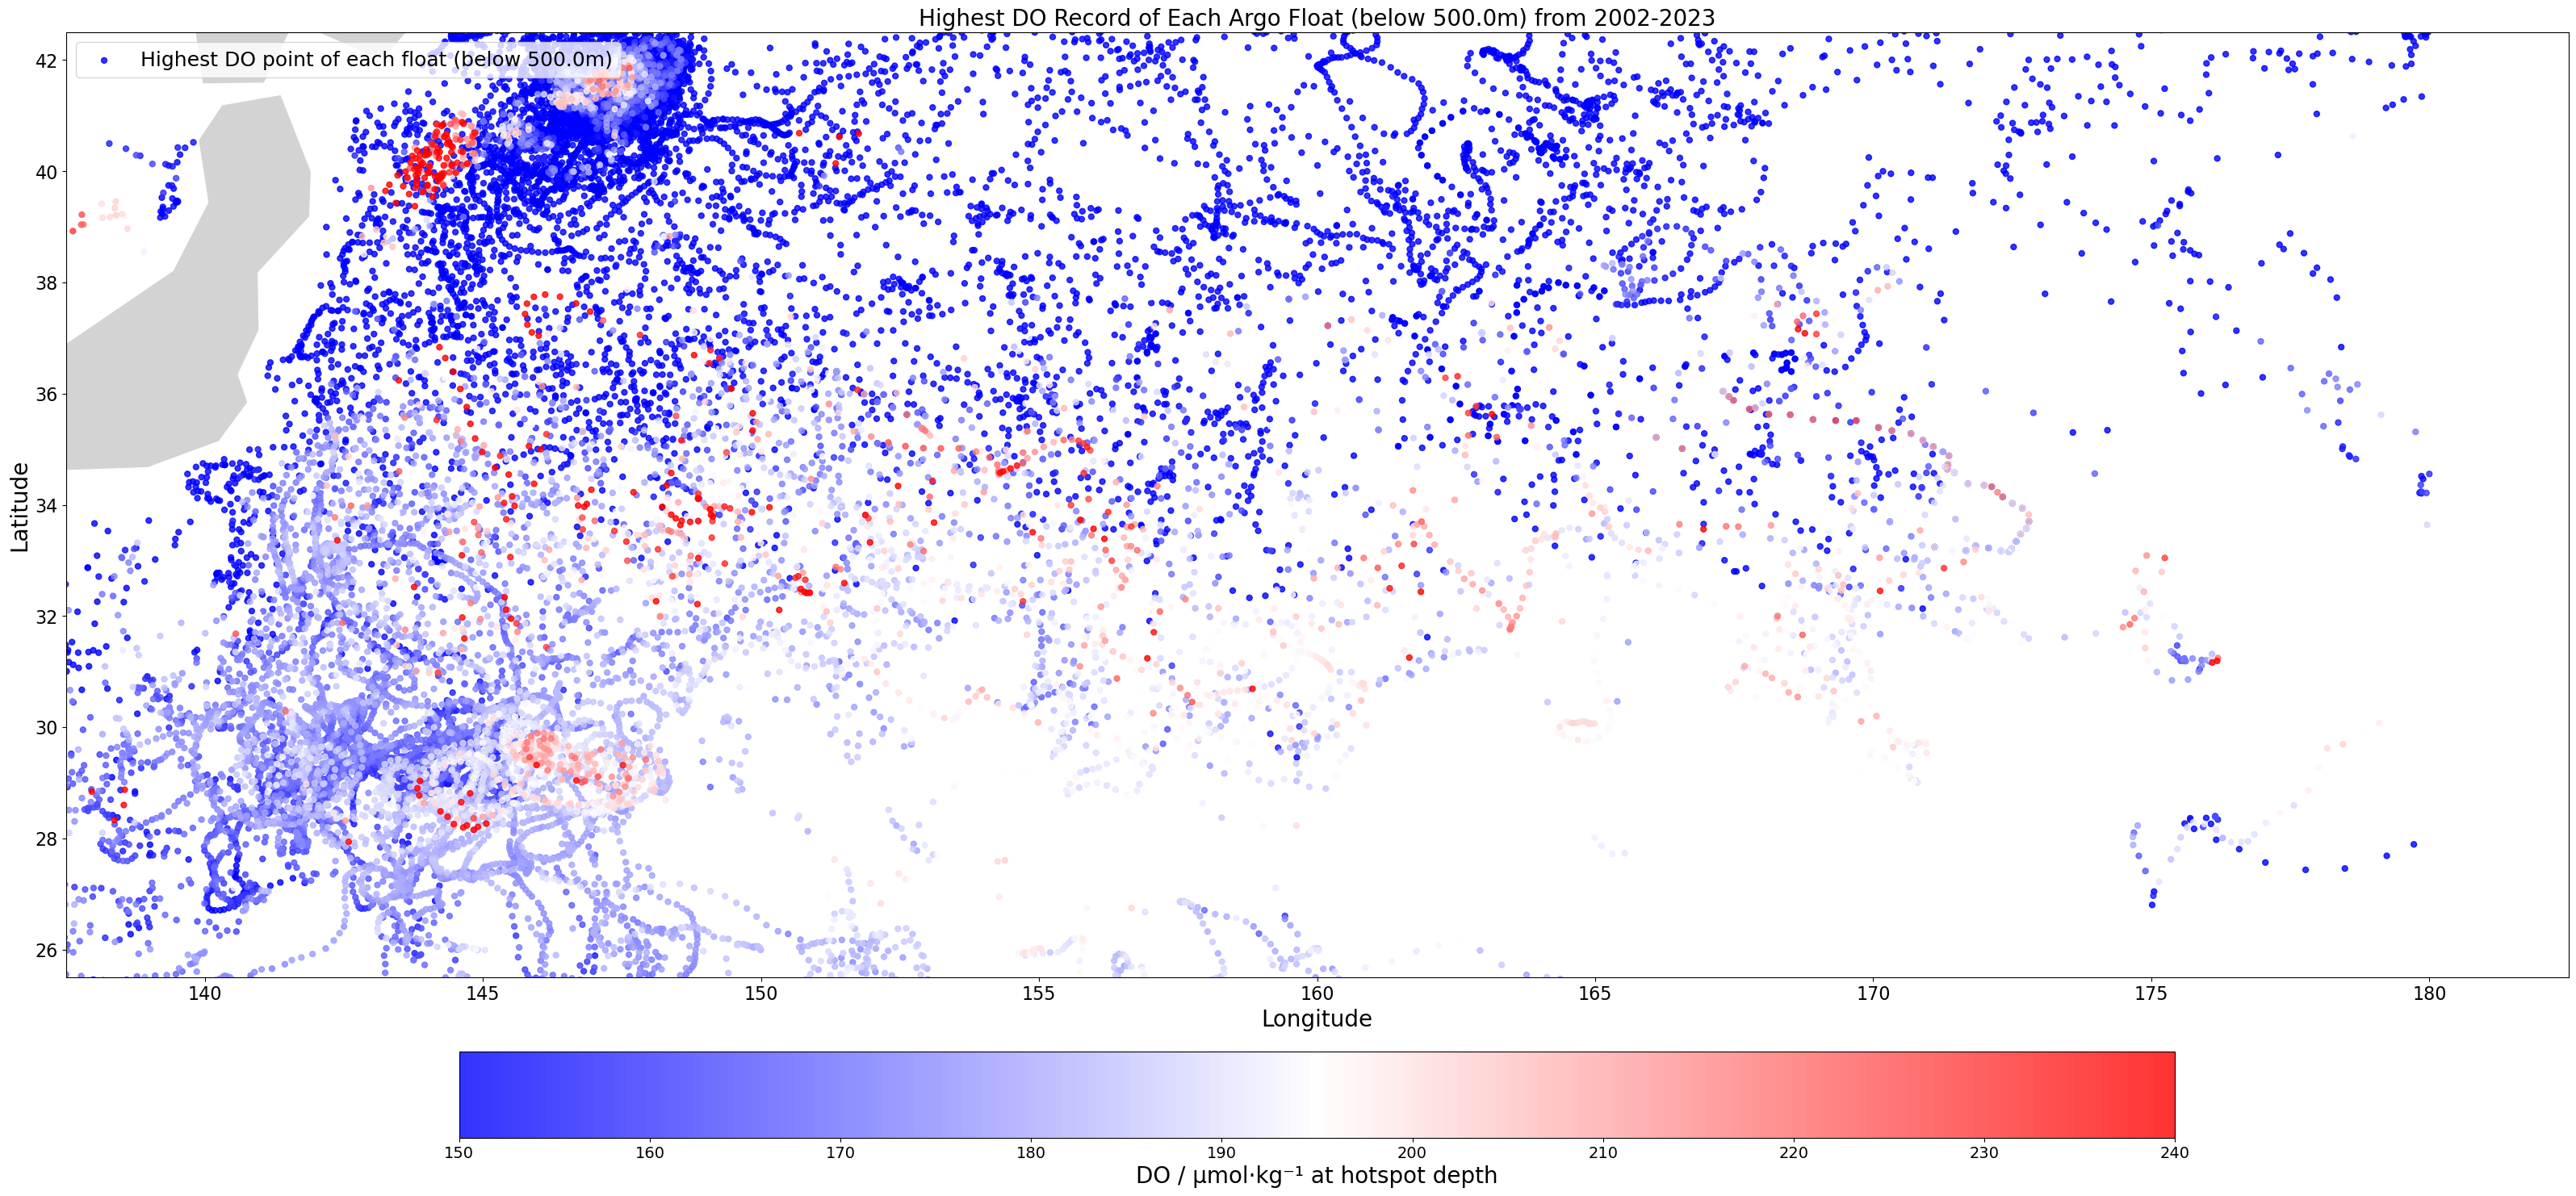

--- Hotspot analysis finished. ---


In [2]:
track.plot_argo_hotspots(
        start_year=2002,
        end_year=2023,
        do_threshold=200.0,
        depth_threshold=500.0,
        save_fig=False,
        show_fig=True
    )

# Find META Track

In [2]:
with open('acs.pkl', 'rb') as f:
    acs = pickle.load(f)

with open('acl.pkl', 'rb') as f:
    acl = pickle.load(f)

with open('cs.pkl', 'rb') as f:
    cs = pickle.load(f)

with open('cl.pkl', 'rb') as f:
    cl = pickle.load(f)

/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:325: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


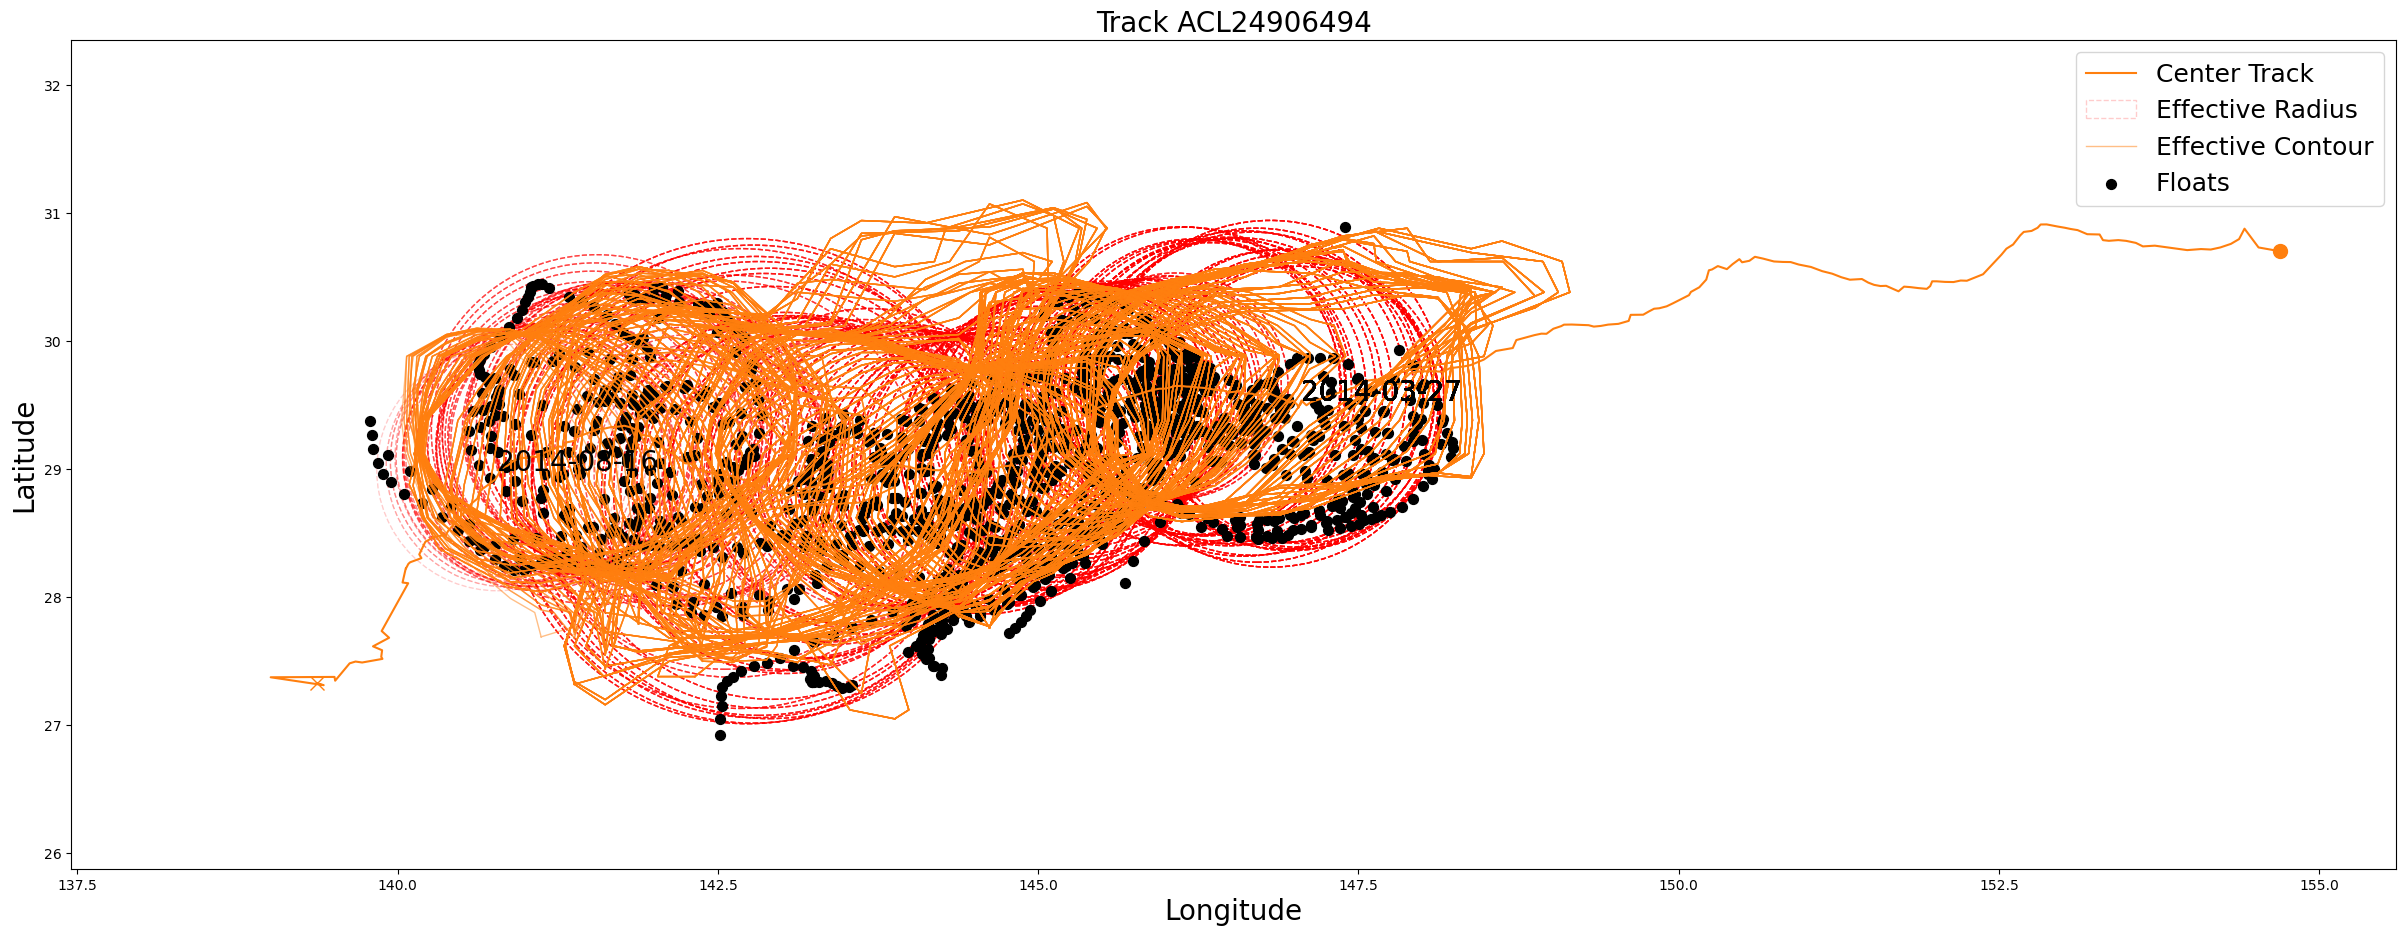

In [3]:
track.plot_track(acl, 24906494)

In [4]:
track.argo_data= track.load_argo_data(2013)

Attempting to load Argo data from: ./Argo_data/Argo2013.parquet
Argo data loaded successfully.


/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:325: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


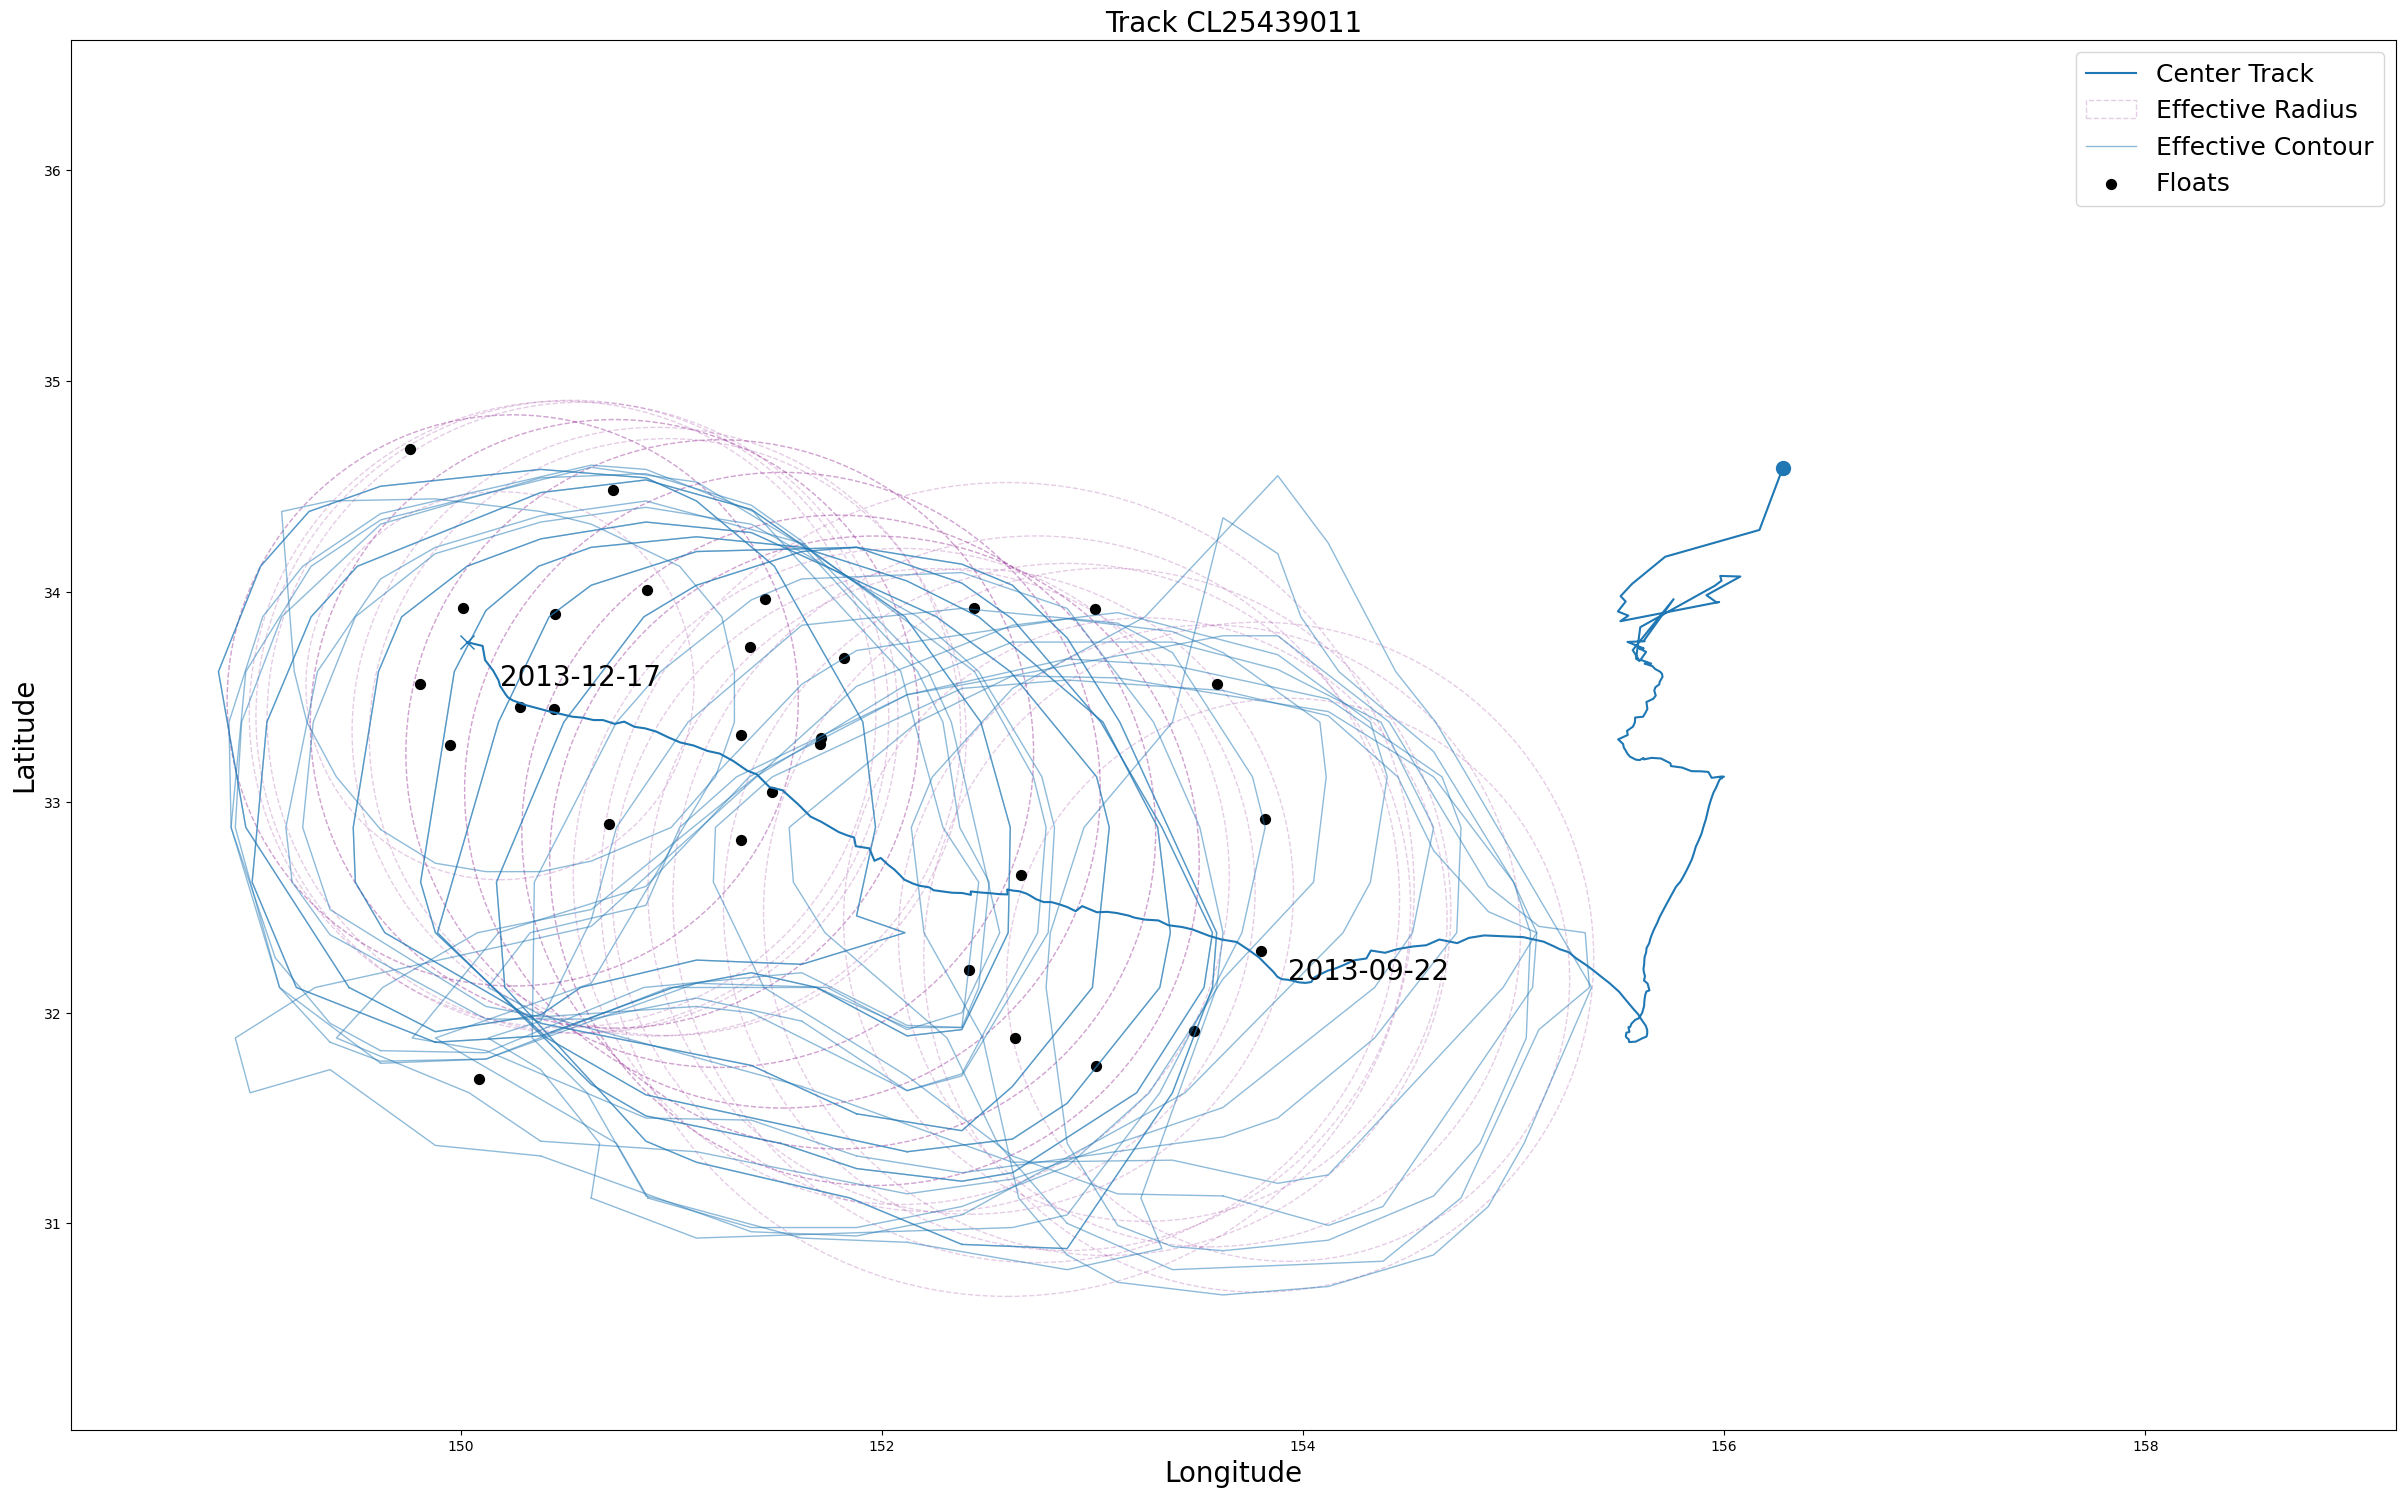

In [5]:
track.plot_track(cl, 25439011)

In [6]:
wanted_track=track.find_track(acl, 24906494)
# wanted_track=track.find_track(cl, 25439011)
num, time, center_lon, center_lat, max_lon, max_lat, contour_lon, contour_lat, radius, speed_contour_lon, speed_contour_lat = zip(*wanted_track)

In [7]:
max_val = -999
max_idx = 0
for i in range(len(contour_lon)):

    max_lon = np.max(contour_lon[i])
    if max_lon > max_val:
        max_val = max_lon
        max_idx = i
print(f"Maximum longitude in contour_lon: {max_val} at index {max_idx}")


min_val = 999
min_idx = 0
for i in range(len(contour_lat)):

    min_lat = np.min(contour_lat[i])
    if min_lat < min_val:
        min_val = min_lat
        min_idx = i
print(f"Minimum latitude in contour_lat: {min_val} at index {min_idx}")

Maximum longitude in contour_lon: 180.0 at index 105
Minimum latitude in contour_lat: 0.0 at index 105


In [8]:
for i in range(len(contour_lon)):
    if contour_lon[i][0] == 180:
        print(f"Index of contour_lon with first element 180: {i}")

Index of contour_lon with first element 180: 105
Index of contour_lon with first element 180: 274
Index of contour_lon with first element 180: 275
Index of contour_lon with first element 180: 280


In [9]:
track.convert_date(time[274])

Timestamp('2014-09-01 00:00:00')

In [10]:
wanted_track[274]

[24906768,
 23619,
 140.15611,
 28.293898,
 140.2914,
 28.63146,
 array([180., 180., 180., 180., 180., 180., 180., 180., 180., 180., 180.,
        180., 180., 180., 180., 180., 180., 180., 180., 180.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 62100.0,
 array([180., 180., 180., 180., 180., 180., 180., 180., 180., 180., 180.,
        180., 180., 180., 180., 180., 180., 180., 180., 180.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.])]

# Utilize Depth Data

In [2]:
with open('acs.pkl', 'rb') as f:
    acs = pickle.load(f)

with open('acl.pkl', 'rb') as f:
    acl = pickle.load(f)

with open('cs.pkl', 'rb') as f:
    cs = pickle.load(f)

with open('cl.pkl', 'rb') as f:
    cl = pickle.load(f)

In [3]:
argo_data = pd.read_parquet("Argo2014.parquet")
print(np.unique(argo_data["Datasets_number"])) #datasets_number==1 means Argo data

argo_data = pd.read_parquet("Argo2013.parquet")
print(np.unique(argo_data["Datasets_number"])) #datasets_number==1 means Argo data


[1.]
[1.]


## Track platform

In [4]:
track.plot_vertical(acl, 24883861, save_fig=True)

track.plot_vertical(acl, 24883861, save_fig=True, variable='Temp')

track.plot_relative_position(acl, 24883861, save_fig=True)

In [5]:
track.plot_vertical(acl, 25380376, save_fig=True)

track.plot_vertical(acl, 25380376, save_fig=True, variable='Temp')

track.plot_relative_position(acl, 25380376, save_fig=True)

In [6]:
# track.plot_vertical(cl, 26073128, save_fig=True)

# track.plot_relative_position(cl, 26073128, save_fig=True)

In [7]:
track.plot_vertical(cl, 26110937, save_fig=True)

track.plot_vertical(cl, 26110937, save_fig=True, variable='Temp')

track.plot_relative_position(cl, 26110937, save_fig=True)

In [8]:
track.plot_vertical(cl, 26327302, save_fig=True)

track.plot_vertical(cl, 26327302, save_fig=True, variable='Temp')

track.plot_relative_position(cl, 26327302, save_fig=True)

In [9]:
track.argo_data= pd.read_parquet("Argo2013.parquet")

In [10]:
track.plot_vertical(cl, 24266000, save_fig=True)

track.plot_vertical(cl, 24266000, save_fig=True, variable='Temp')

track.plot_relative_position(cl, 24266000, save_fig=True)

In [11]:
track.plot_vertical(acl, 24546743, save_fig=True)

track.plot_vertical(acl, 24546743, save_fig=True, variable='Temp')

track.plot_relative_position(acl, 24546743, save_fig=True)

In [12]:
# track.plot_vertical(cl, 24906981, save_fig=True)

# track.plot_relative_position(cl, 24906981, save_fig=True)

# track.plot_vertical(cl, 25704129, save_fig=True)

# track.plot_relative_position(cl, 25704129, save_fig=True)

## Track Date

In [13]:
track.plot_vertical_monthly(cl, 24266000,[9,10], save_fig=True)
track.plot_vertical_monthly(cl, 24266000,[9,10], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(cl, 24266000,[9,10], save_fig=True)

track.plot_vertical_monthly(cl, 24266000,[11,12], save_fig=True)
track.plot_vertical_monthly(cl, 24266000,[11,12], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(cl, 24266000,[11,12], save_fig=True)

Figure saved to: plot_vertical_DO_monthly_aggregated/CL24266000_DO_months_9_10_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/CL24266000_Temp_months_9_10_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/CL24266000_RP_months_9_10_aggregated.png
Figure saved to: plot_vertical_DO_monthly_aggregated/CL24266000_DO_months_11_12_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/CL24266000_Temp_months_11_12_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/CL24266000_RP_months_11_12_aggregated.png


In [16]:
track.plot_vertical_monthly(acl, 24546743,[8], save_fig=True)
track.plot_vertical_monthly(acl, 24546743,[8], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(acl, 24546743,[8], save_fig=True)

track.plot_vertical_monthly(acl, 24546743,[9], save_fig=True)
track.plot_vertical_monthly(acl, 24546743,[9], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(acl, 24546743,[9], save_fig=True)

Figure saved to: plot_vertical_DO_monthly_aggregated/ACL24546743_DO_months_8_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/ACL24546743_Temp_months_8_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/ACL24546743_RP_months_8_aggregated.png
Figure saved to: plot_vertical_DO_monthly_aggregated/ACL24546743_DO_months_9_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/ACL24546743_Temp_months_9_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/ACL24546743_RP_months_9_aggregated.png


In [17]:
track.argo_data= pd.read_parquet("Argo2014.parquet")

In [18]:
track.plot_vertical_monthly(acl, 24883861, [3,4], save_fig=True)
track.plot_vertical_monthly(acl, 24883861, [3,4], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(acl, 24883861, [3,4], save_fig=True)

track.plot_vertical_monthly(acl, 24883861, [5,6], save_fig=True)
track.plot_vertical_monthly(acl, 24883861, [5,6], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(acl, 24883861, [5,6], save_fig=True)

track.plot_vertical_monthly(acl, 24883861, [7,8], save_fig=True)
track.plot_vertical_monthly(acl, 24883861, [7,8], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(acl, 24883861, [7,8], save_fig=True)

Figure saved to: plot_vertical_DO_monthly_aggregated/ACL24883861_DO_months_3_4_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/ACL24883861_Temp_months_3_4_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/ACL24883861_RP_months_3_4_aggregated.png
Figure saved to: plot_vertical_DO_monthly_aggregated/ACL24883861_DO_months_5_6_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/ACL24883861_Temp_months_5_6_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/ACL24883861_RP_months_5_6_aggregated.png
Figure saved to: plot_vertical_DO_monthly_aggregated/ACL24883861_DO_months_7_8_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/ACL24883861_Temp_months_7_8_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/ACL24883861_RP_months_7_8_aggregated.png


In [19]:
track.plot_vertical_monthly(cl, 26110937,[4], save_fig=True)
track.plot_vertical_monthly(cl, 26110937,[4], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(cl, 26110937,[4], save_fig=True)

track.plot_vertical_monthly(cl, 26110937,[5], save_fig=True)
track.plot_vertical_monthly(cl, 26110937,[5], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(cl, 26110937,[5], save_fig=True)

track.plot_vertical_monthly(cl, 26110937,[6], save_fig=True)
track.plot_vertical_monthly(cl, 26110937,[6], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(cl, 26110937,[6], save_fig=True)

Figure saved to: plot_vertical_DO_monthly_aggregated/CL26110937_DO_months_4_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/CL26110937_Temp_months_4_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/CL26110937_RP_months_4_aggregated.png
Figure saved to: plot_vertical_DO_monthly_aggregated/CL26110937_DO_months_5_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/CL26110937_Temp_months_5_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/CL26110937_RP_months_5_aggregated.png
Figure saved to: plot_vertical_DO_monthly_aggregated/CL26110937_DO_months_6_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/CL26110937_Temp_months_6_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/CL26110937_RP_months_6_aggregated.png


# Read GLORYS Data

In [2]:
with open('acs.pkl', 'rb') as f:
    acs = pickle.load(f)

with open('acl.pkl', 'rb') as f:
    acl = pickle.load(f)

with open('cs.pkl', 'rb') as f:
    cs = pickle.load(f)

with open('cl.pkl', 'rb') as f:
    cl = pickle.load(f)

In [3]:
nc_path_dict=track.find_track_glorys_filepath(acl, 24883861)

In [4]:
print(list(nc_path_dict.keys())[0])
print(list(nc_path_dict.values())[0])

2013-12-03 00:00:00
../copernicus/GLORYS/2013/12/mercatorglorys12v1_gl12_mean_20131203_R20131204.nc


In [5]:
track.print_glorys_variable(list(nc_path_dict.values())[0])

longitude longitude
('longitude',) (4320,)
latitude latitude
('latitude',) (2041,)
depth depth
('depth',) (50,)
time time
('time',) (1,)
mlotst ocean_mixed_layer_thickness_defined_by_sigma_theta
('time', 'latitude', 'longitude') (1, 2041, 4320)
zos sea_surface_height_above_geoid
('time', 'latitude', 'longitude') (1, 2041, 4320)
bottomT sea_water_potential_temperature_at_sea_floor
('time', 'latitude', 'longitude') (1, 2041, 4320)
sithick sea_ice_thickness
('time', 'latitude', 'longitude') (1, 2041, 4320)
siconc sea_ice_area_fraction
('time', 'latitude', 'longitude') (1, 2041, 4320)
usi eastward_sea_ice_velocity
('time', 'latitude', 'longitude') (1, 2041, 4320)
vsi northward_sea_ice_velocity
('time', 'latitude', 'longitude') (1, 2041, 4320)
thetao sea_water_potential_temperature
('time', 'depth', 'latitude', 'longitude') (1, 50, 2041, 4320)
so sea_water_salinity
('time', 'depth', 'latitude', 'longitude') (1, 50, 2041, 4320)
uo eastward_sea_water_velocity
('time', 'depth', 'latitude', 'lo

In [6]:
glorys_lon_filtered, glorys_lat_filtered, glorys_depth_filtered, glorys_variables_filtered=track.get_track_area_glorys(acl, 24883861, 157, variables=['u', 'v'])

In [7]:
np.set_printoptions(precision=2, suppress=True)
print(glorys_depth_filtered)

[   0.49    1.54    2.65    3.82    5.08    6.44    7.93    9.57   11.4
   13.47   15.81   18.5    21.6    25.21   29.44   34.43   40.34   47.37
   55.76   65.81   77.85   92.33  109.73  130.67  155.85  186.13  222.48
  266.04  318.13  380.21  453.94  541.09  643.57  763.33  902.34 1062.44
 1245.29 1452.25 1684.28 1941.89]


/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:1195: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


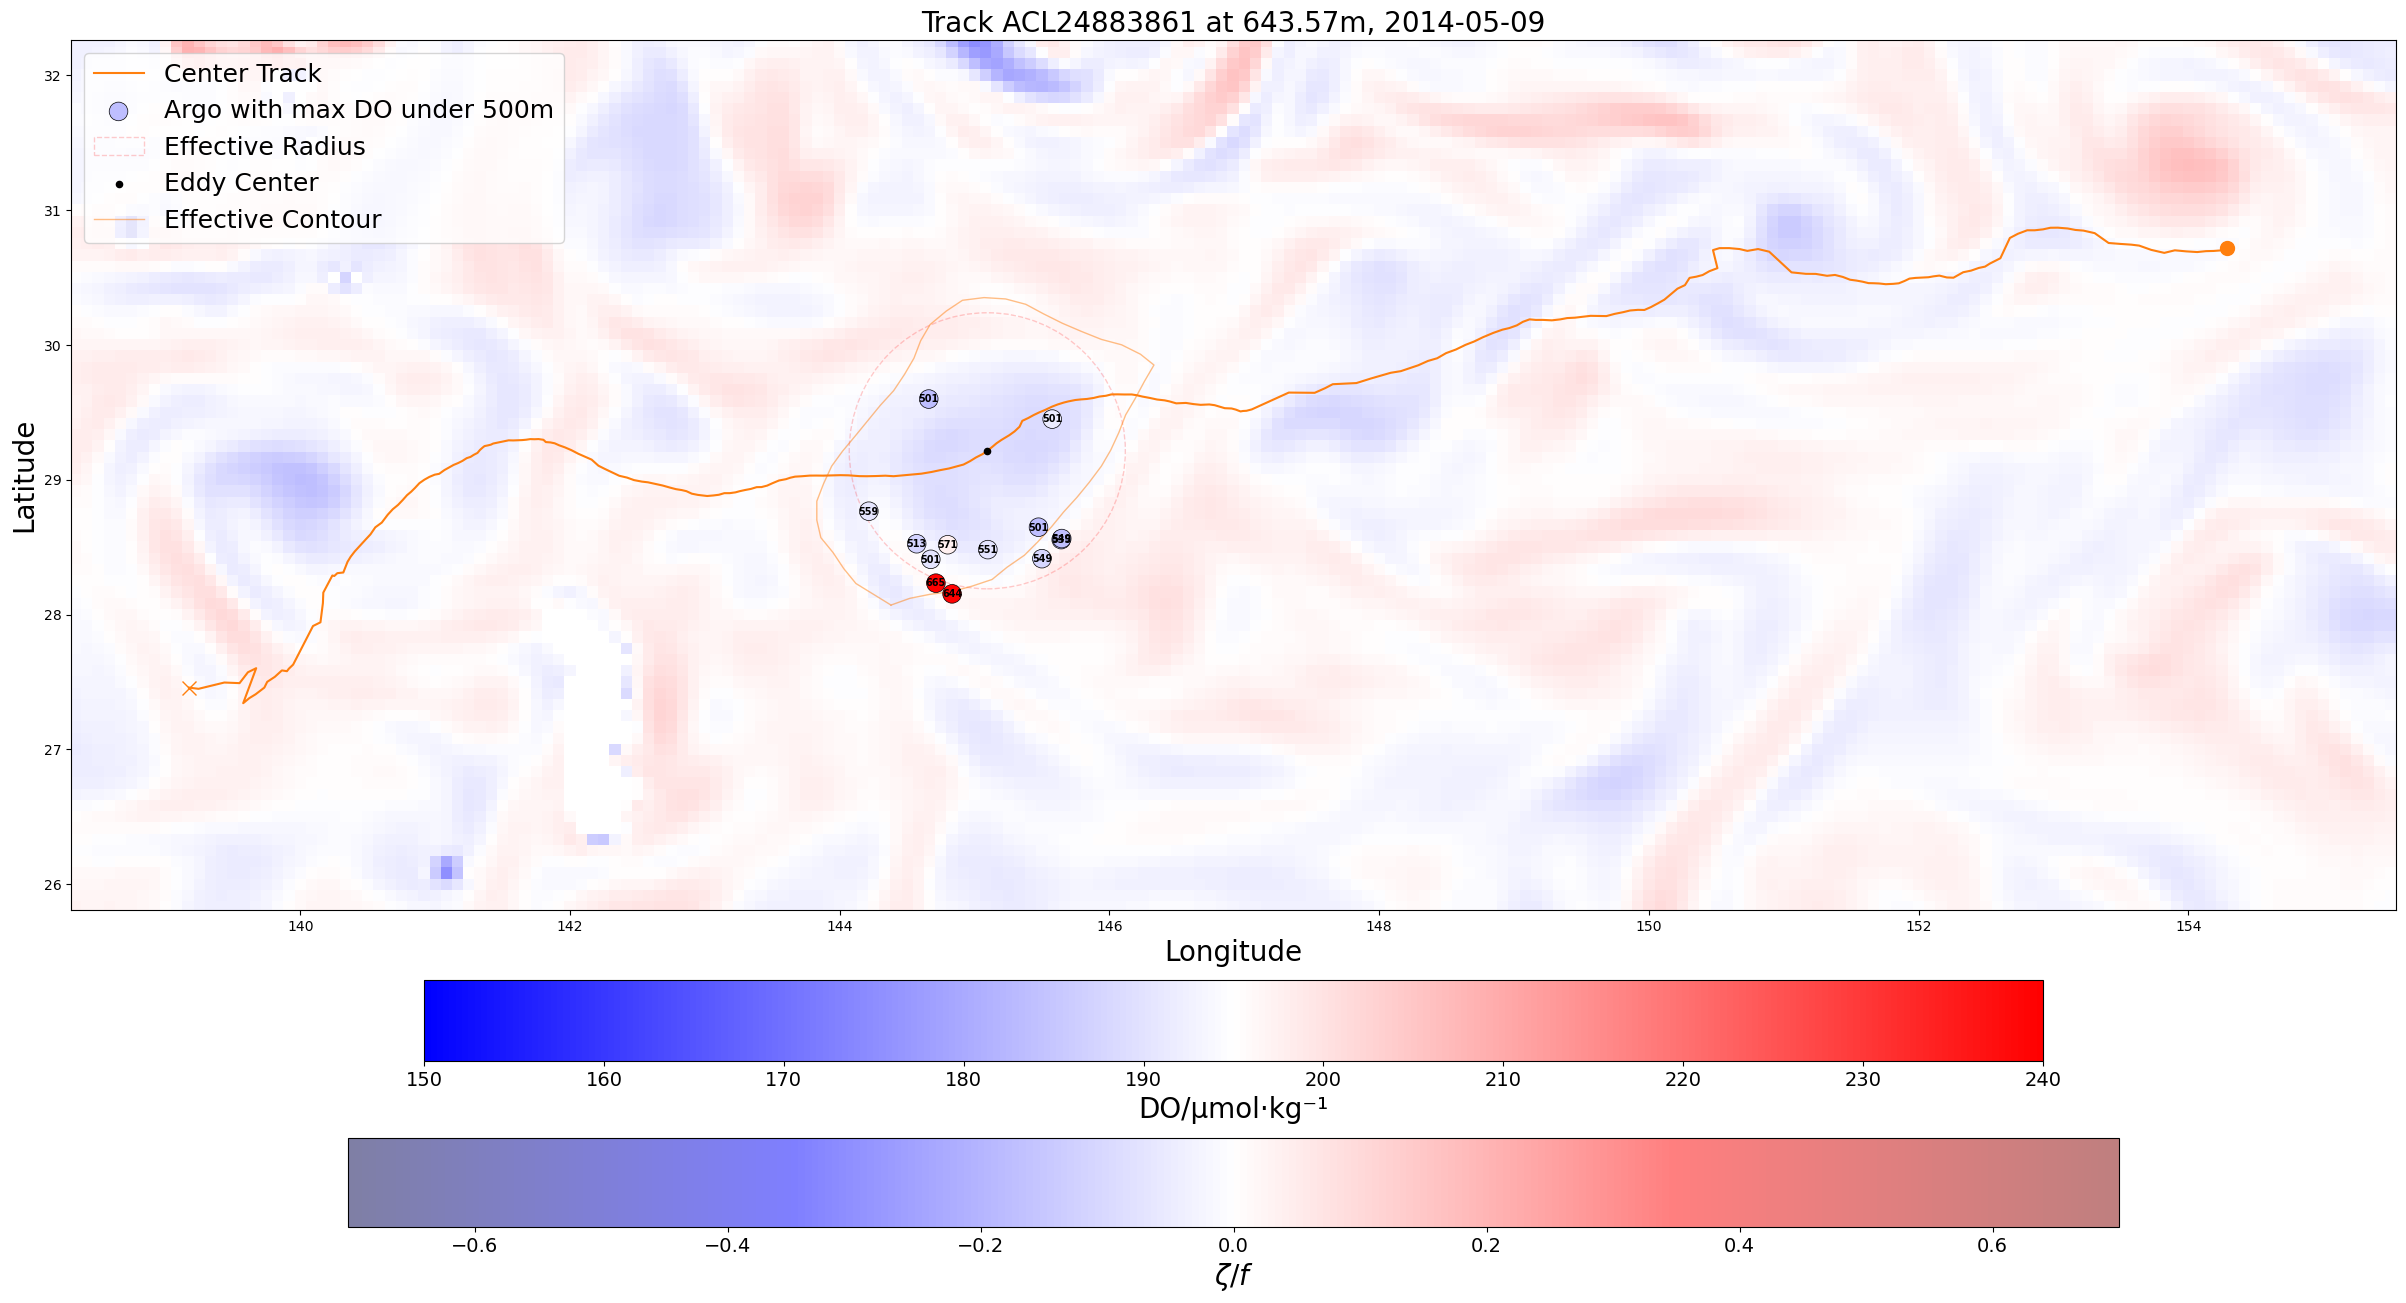

In [8]:
track.plot_track_area_horizontal_glorys(acl, 24883861, 157, show_fig=True, deep_argo=True, needed_depth=650)

/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:1195: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


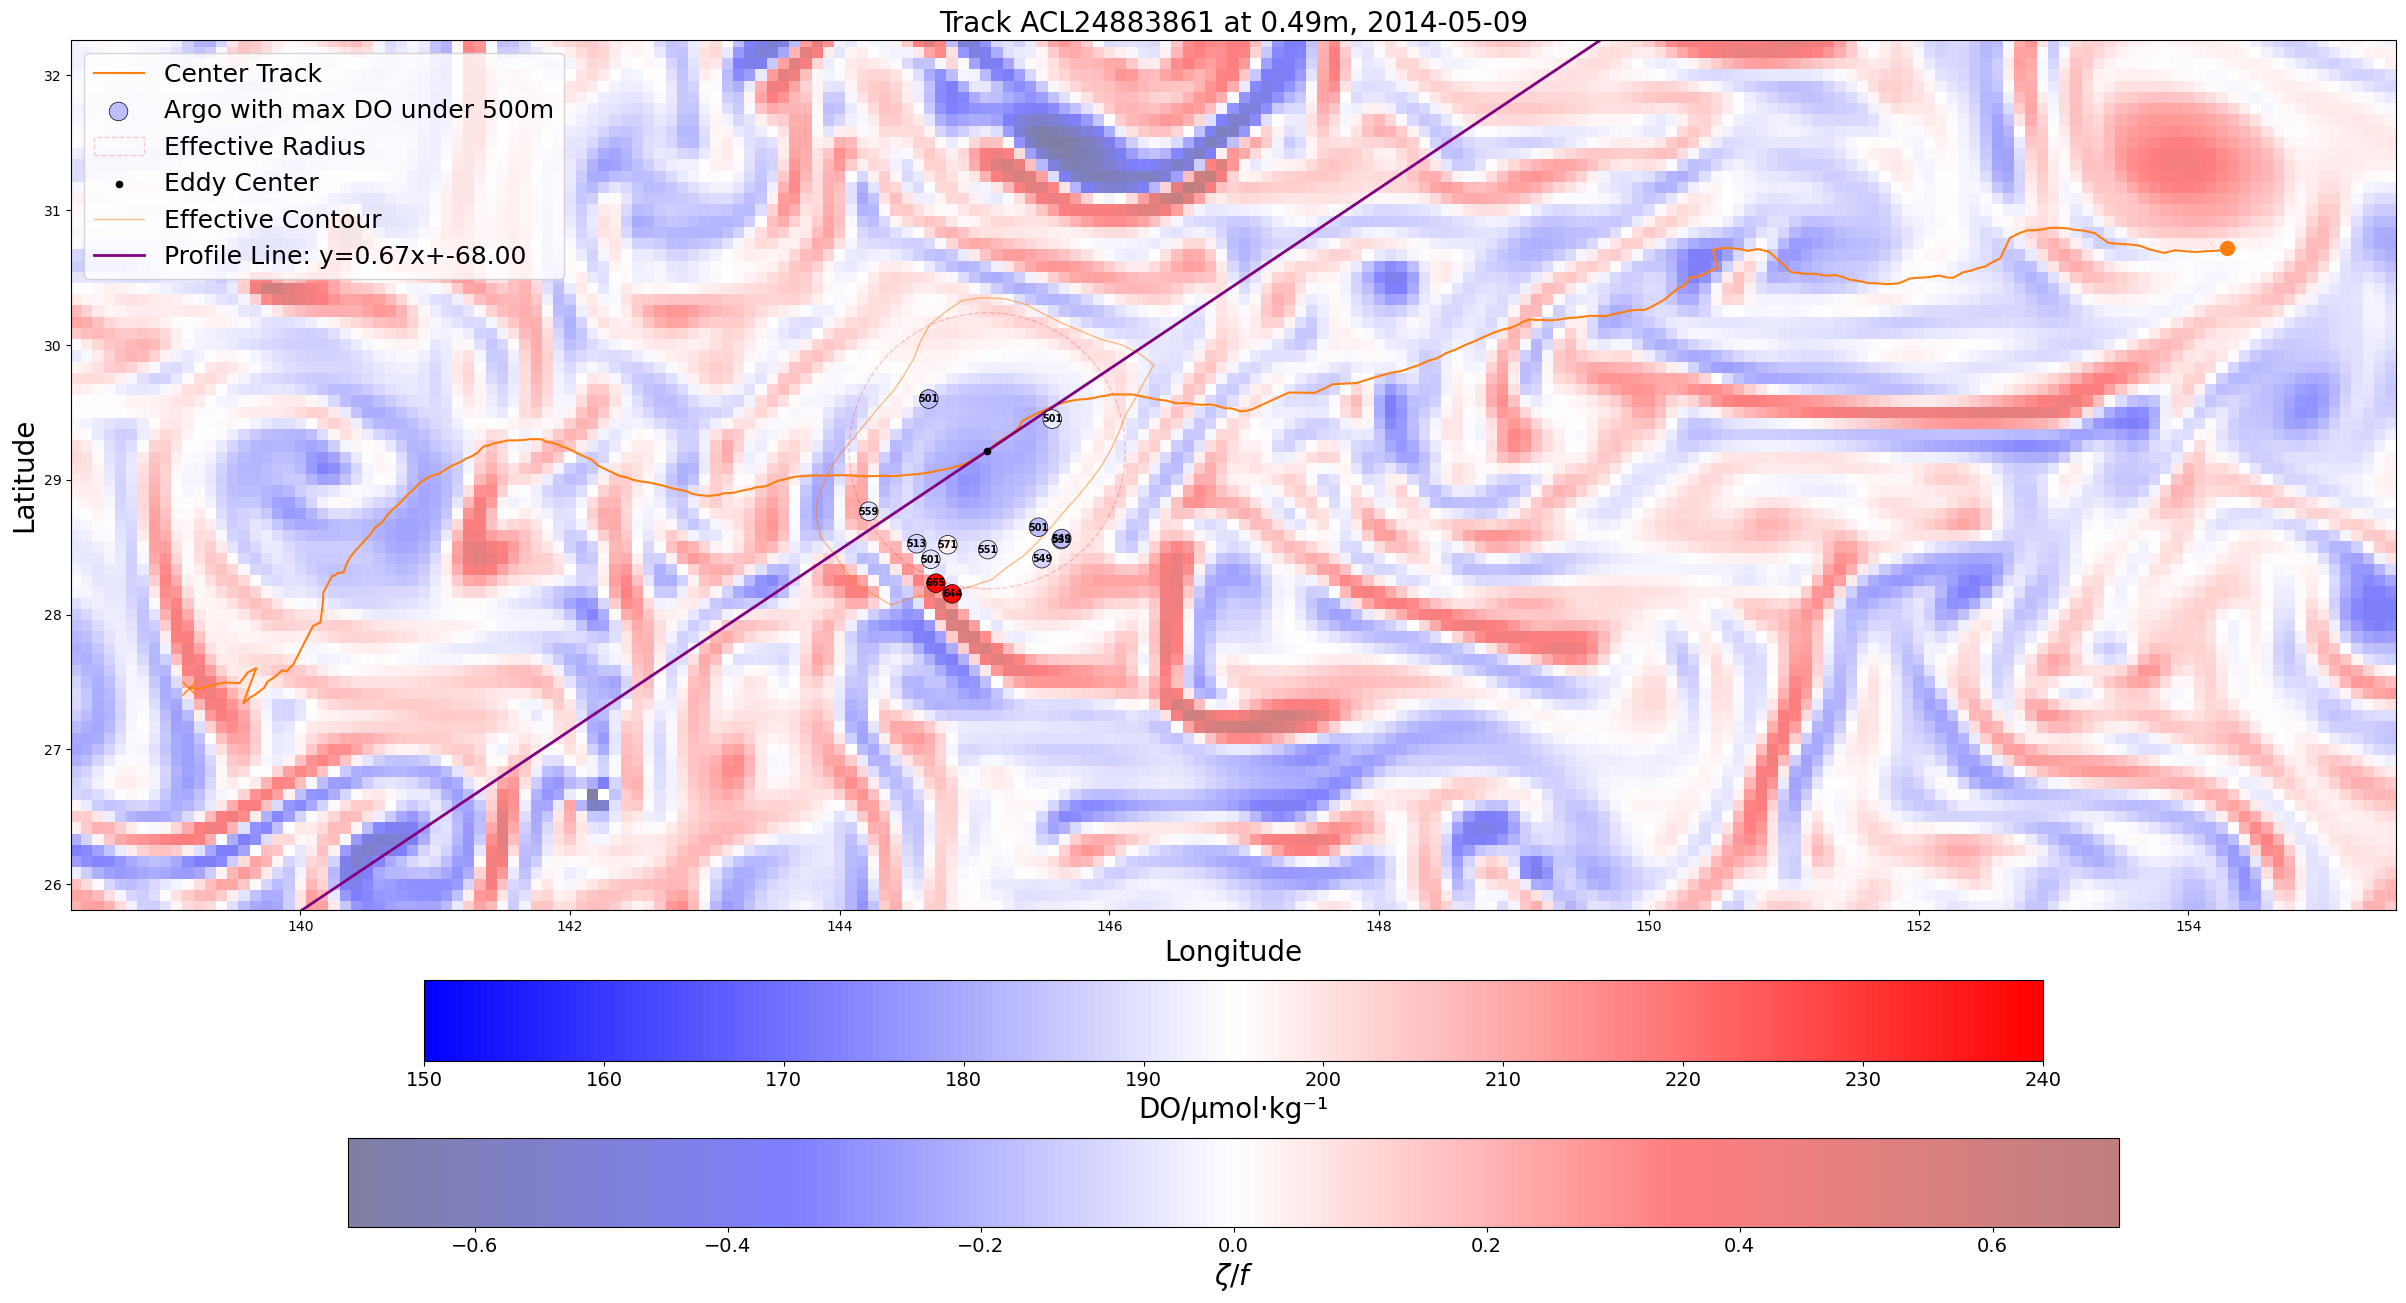

/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:1195: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


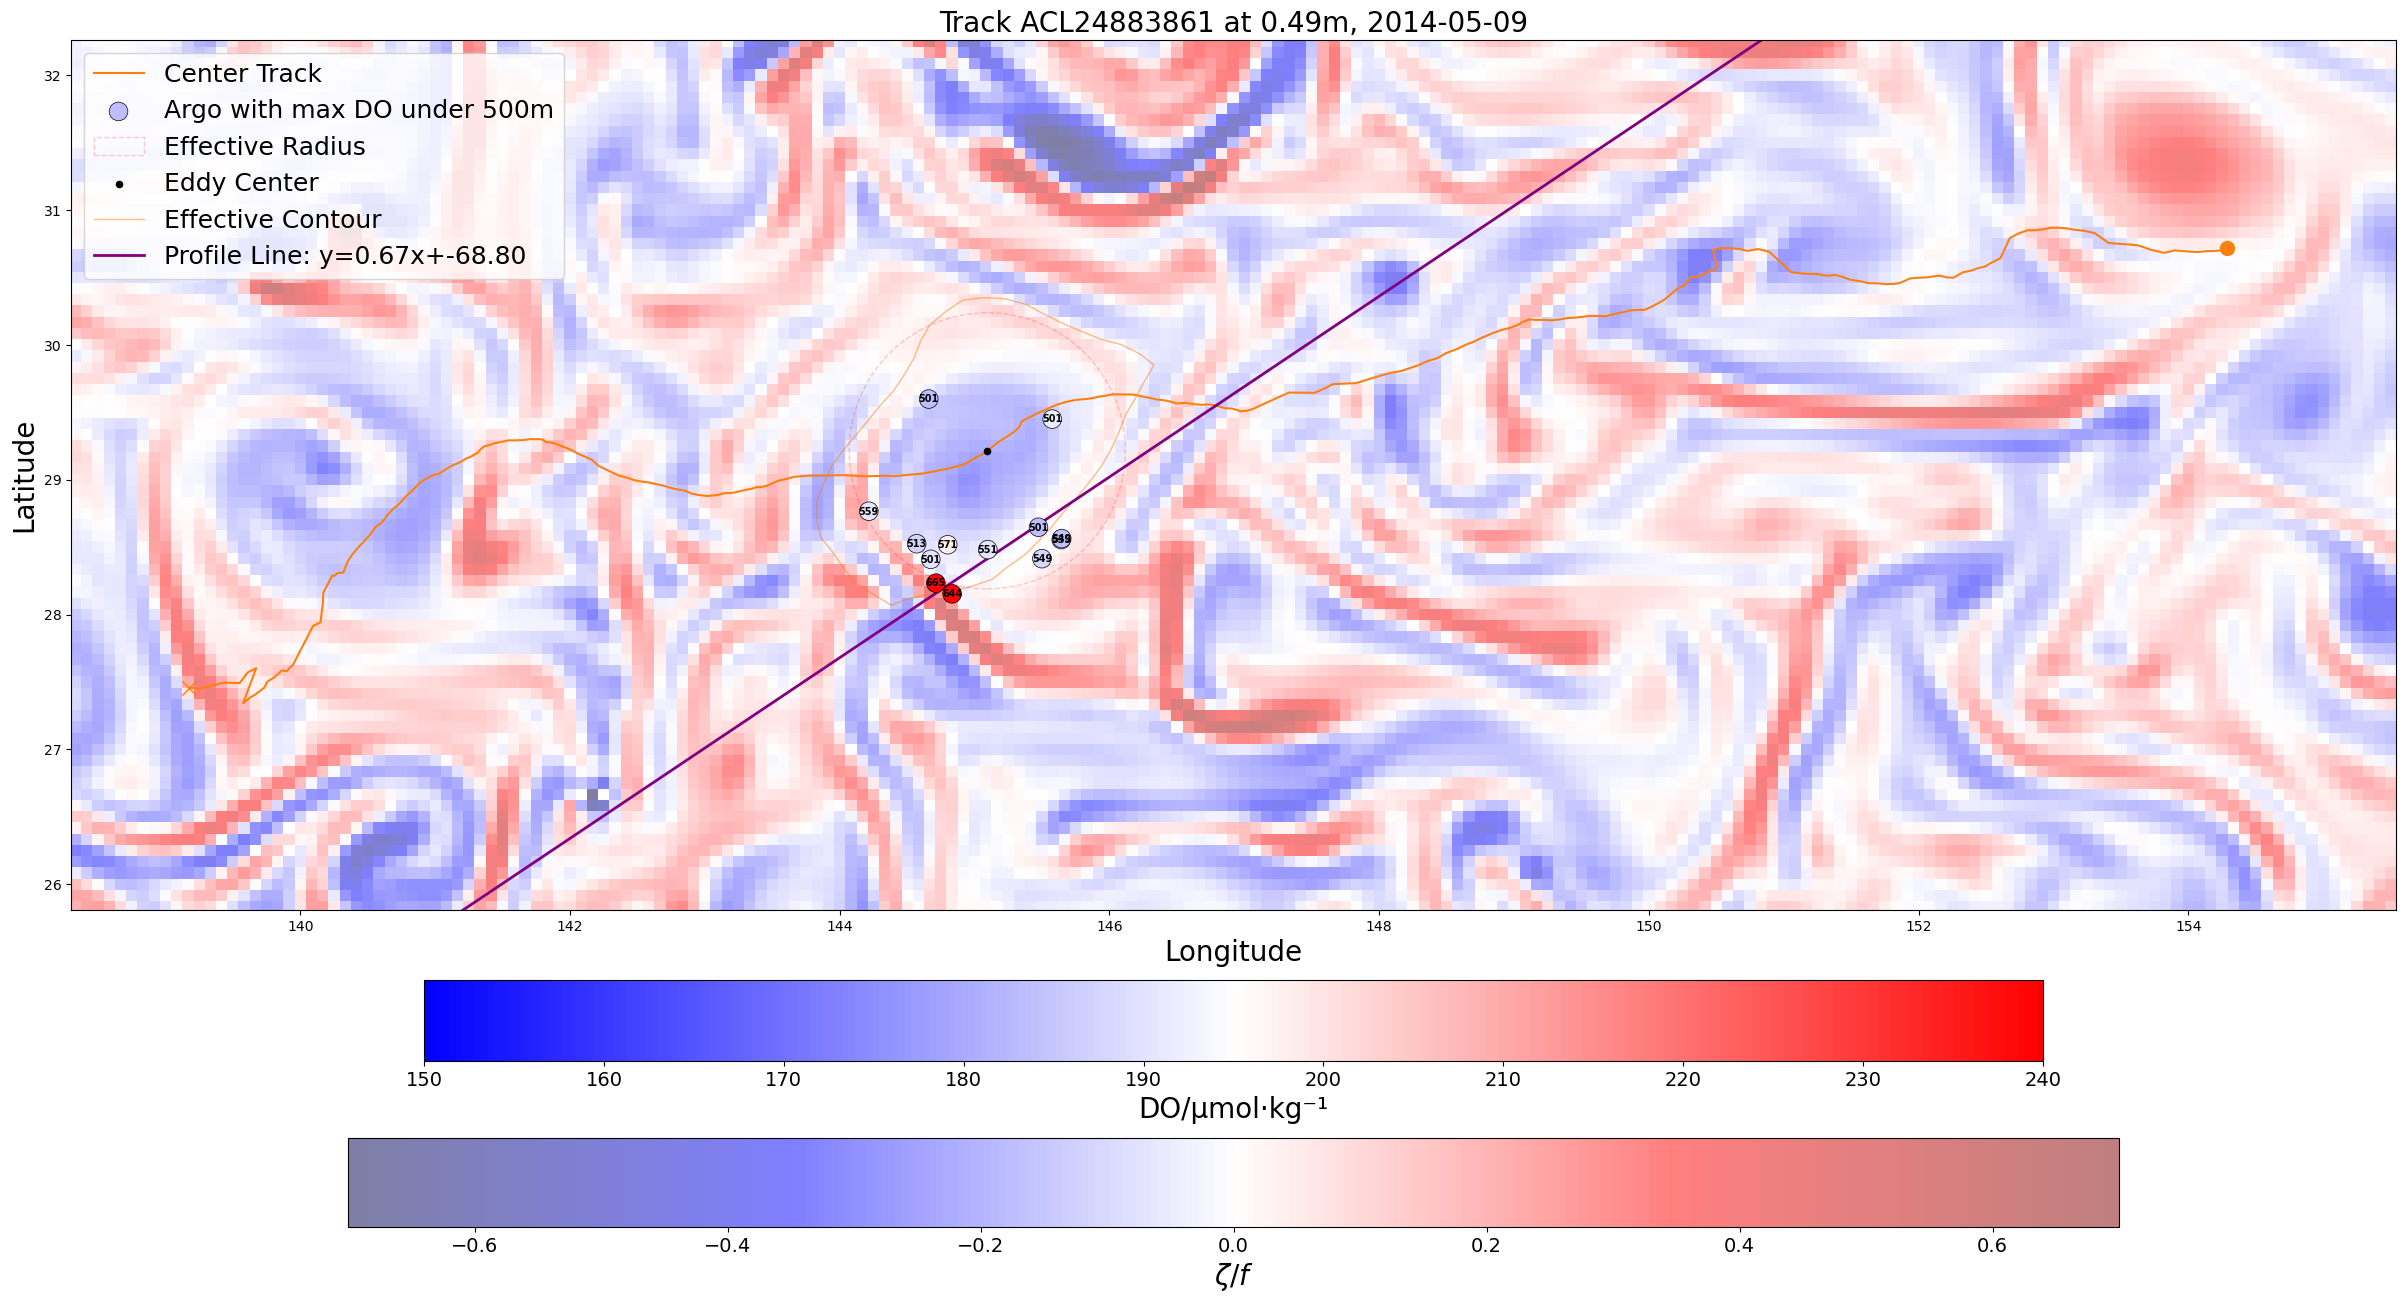

/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:1195: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


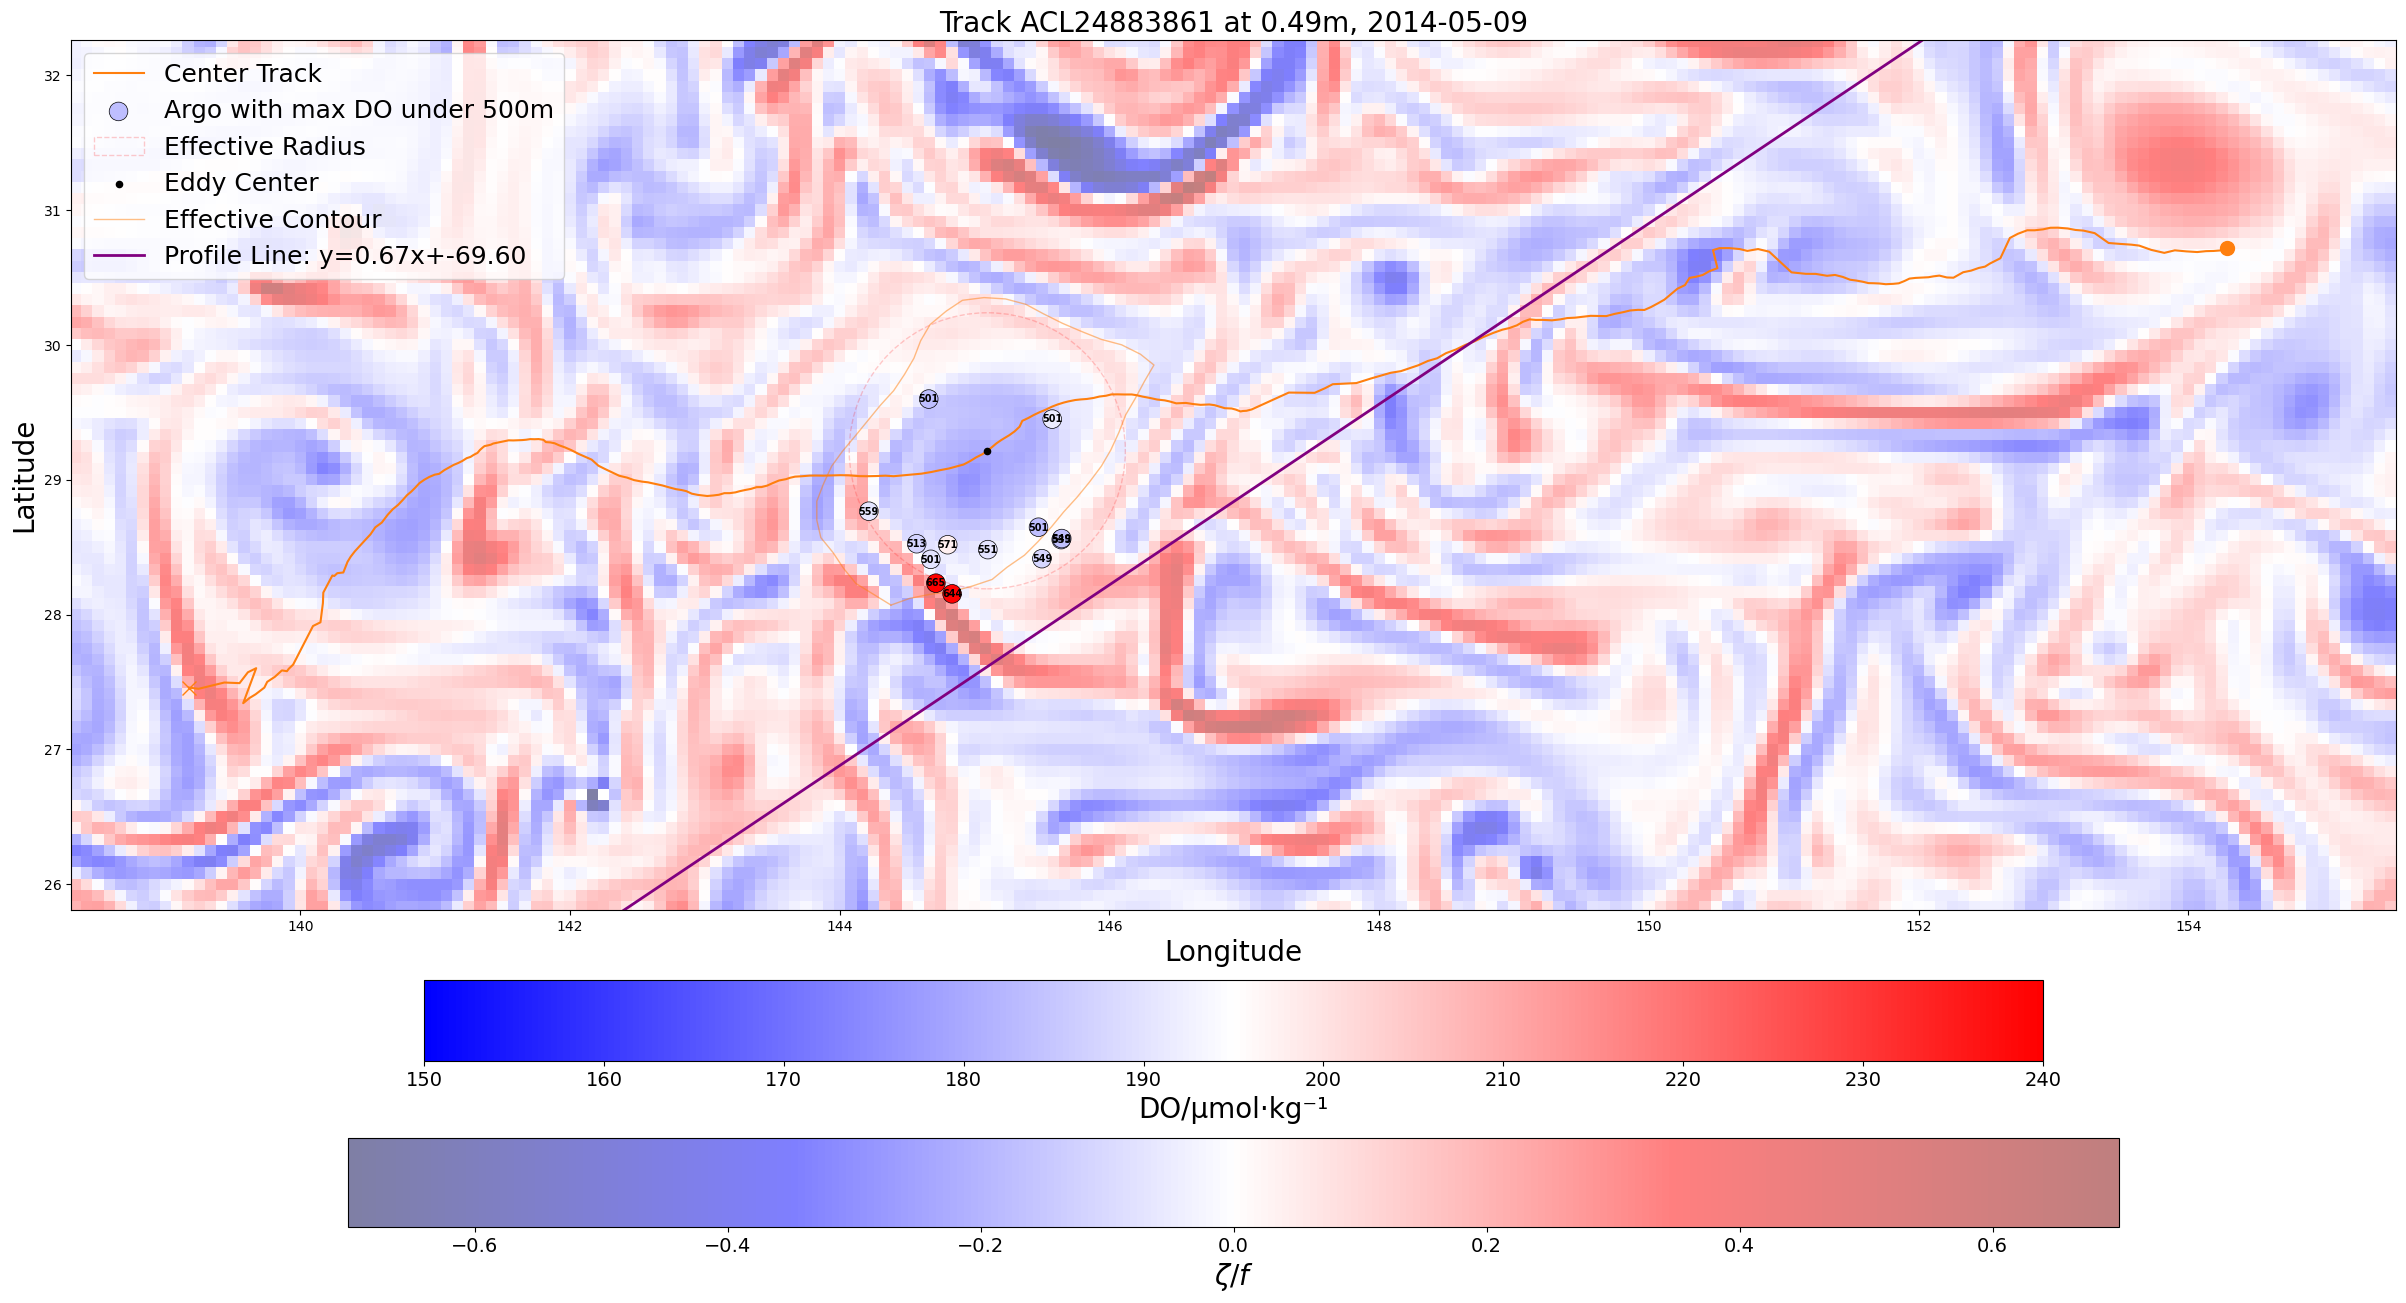

In [9]:
for needed_idx in track.get_idx(acl, 24883861, '2014-05-09', '2014-05-09'):
    track.plot_track_area_horizontal_glorys(acl, 24883861, needed_idx, show_fig=True, deep_argo=True, k=0.67, b=-68)
    track.plot_track_area_horizontal_glorys(acl, 24883861, needed_idx, show_fig=True, deep_argo=True, k=0.67, b=-68.8)
    track.plot_track_area_horizontal_glorys(acl, 24883861, needed_idx, show_fig=True, deep_argo=True, k=0.67, b=-69.6)

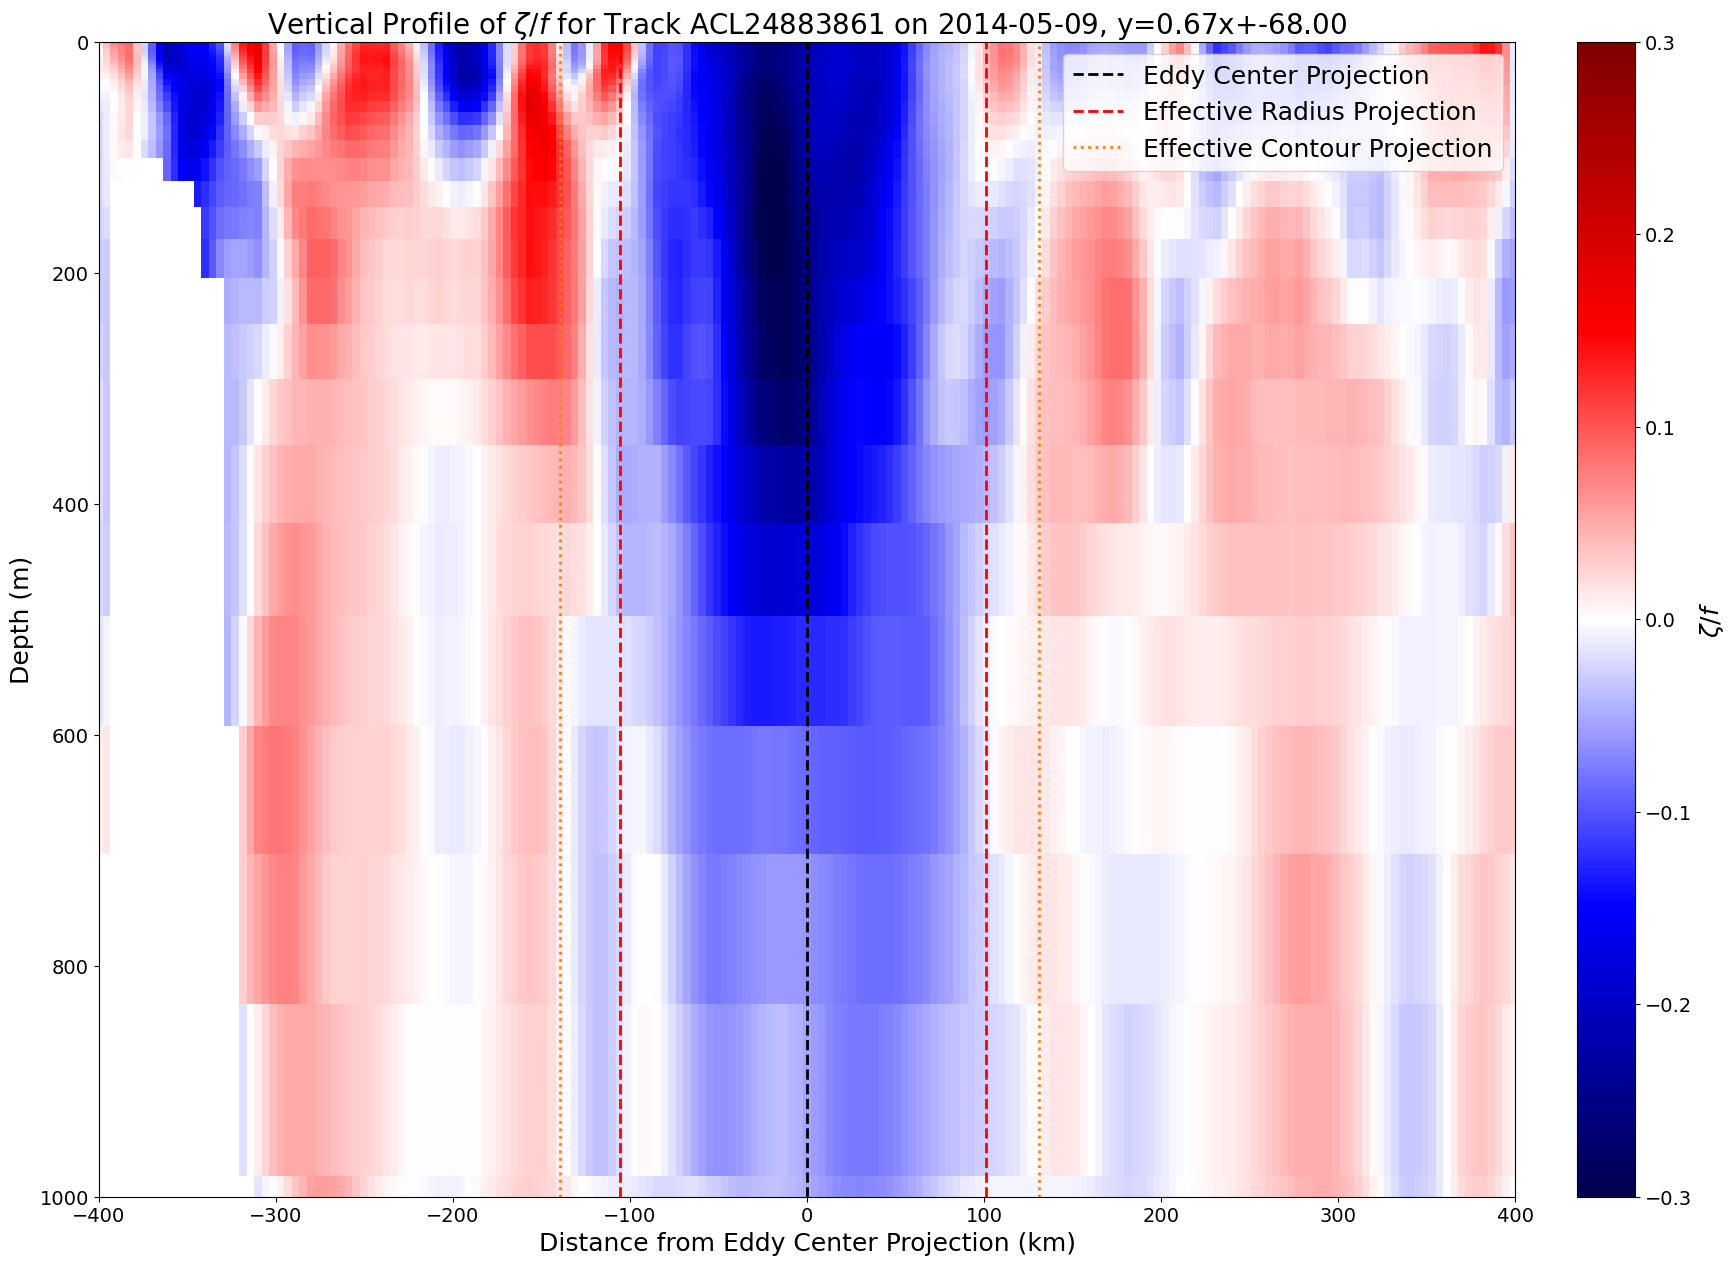

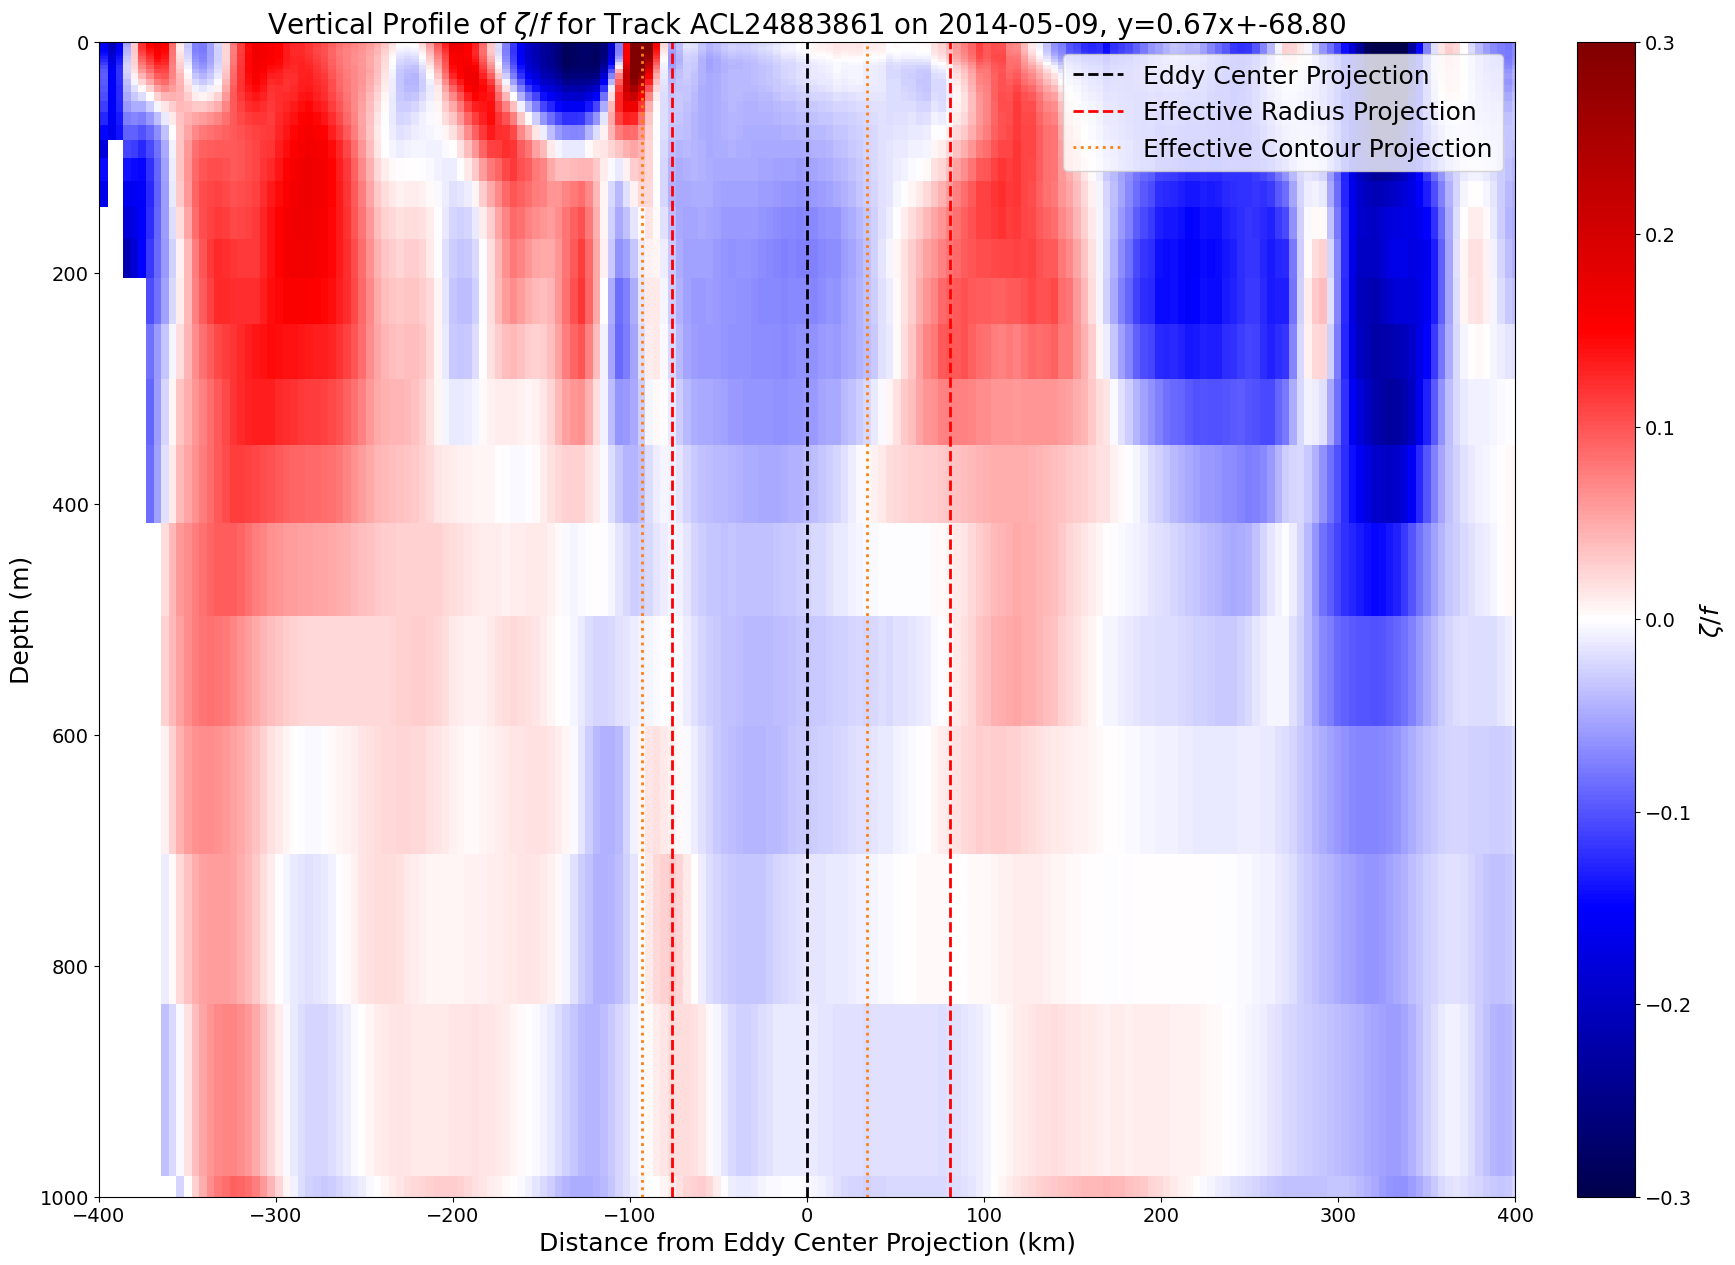

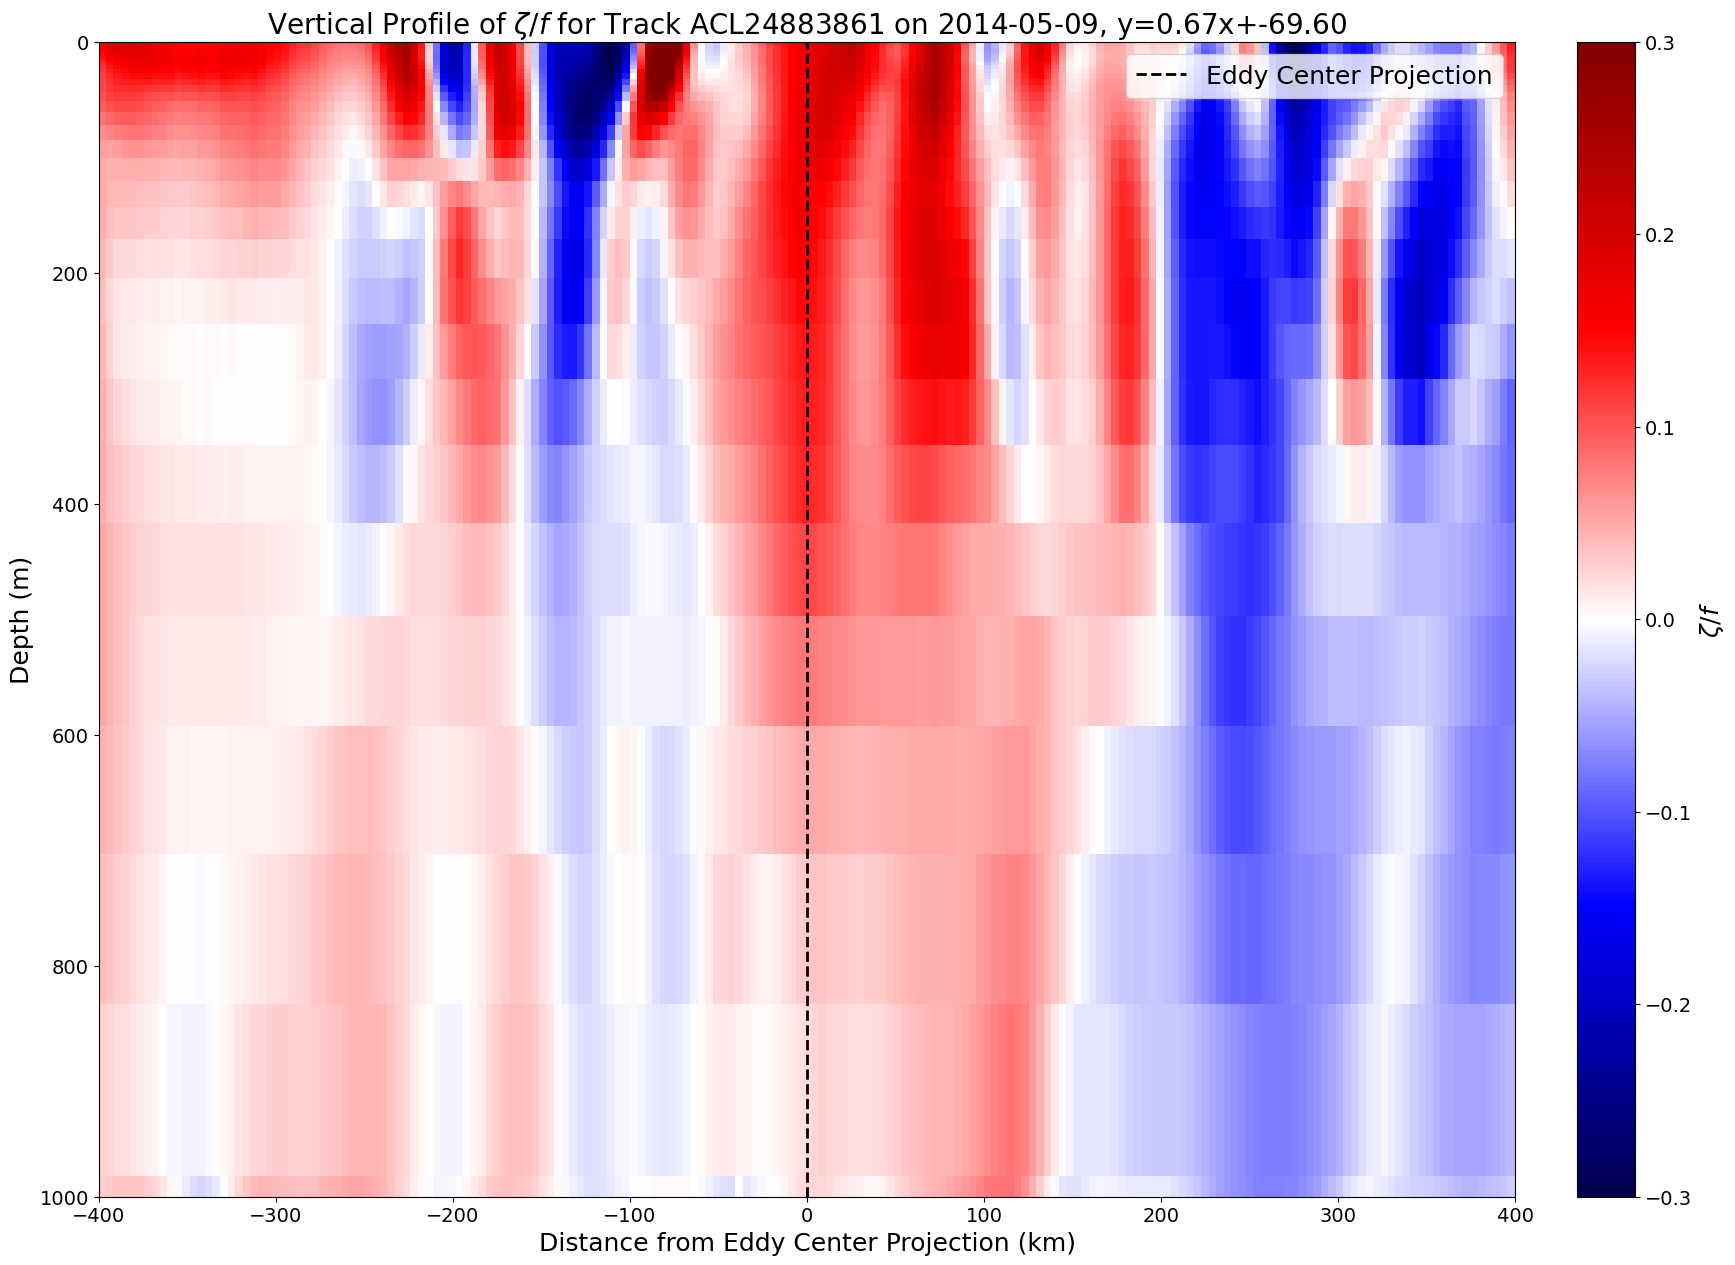

In [10]:
for needed_idx in track.get_idx(acl, 24883861, '2014-05-09', '2014-05-09'):
    track.plot_vertical_glorys(acl, 24883861, needed_idx,k=0.67, b=-68, show_fig=True, xmin=-400,xmax=400,ymin=0,ymax=1000)
    track.plot_vertical_glorys(acl, 24883861, needed_idx, k=0.67, b=-68.8, show_fig=True, xmin=-400, xmax=400, ymin=0, ymax=1000)
    track.plot_vertical_glorys(acl, 24883861, needed_idx, k=0.67, b=-69.6, show_fig=True, xmin=-400, xmax=400, ymin=0, ymax=1000)

In [11]:
for needed_idx in track.get_idx(acl, 24883861, '2014-05-01', '2014-06-30'):
    track.plot_track_area_horizontal_glorys(acl, 24883861, needed_idx, save_fig=True, deep_argo=True)

/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:1194: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


Figure saved to: plot_track_area_horizontal_glorys/ACL24883861_0.49m_vorticity_20140501.png


/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:1194: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


Figure saved to: plot_track_area_horizontal_glorys/ACL24883861_0.49m_vorticity_20140502.png


/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:1194: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


...

Figure saved to: plot_track_area_horizontal_glorys/ACL24883861_0.49m_vorticity_20140628.png


/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:1194: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


Figure saved to: plot_track_area_horizontal_glorys/ACL24883861_0.49m_vorticity_20140629.png


/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:1194: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


Figure saved to: plot_track_area_horizontal_glorys/ACL24883861_0.49m_vorticity_20140630.png


## Test

In [7]:
acl_track_1=track.find_track(acl, 24883861)
test_eddy=acl_track_1[114]
test_date=track.convert_date(test_eddy[1])
print(test_date)

2014-03-27 00:00:00


In [8]:
Glorys_path = '../copernicus/GLORYS'
test_path = os.path.join(Glorys_path, test_date.strftime("%Y"), test_date.strftime("%m"), 'mercatorglorys12v1_gl12_mean_')
test_path += test_date.strftime("%Y%m%d")
matches = glob.glob(test_path + '_R*')
if matches:
    test_path = matches[0]
    print("Matching file:", test_path)
else:
    print("No matching file found.")

Matching file: ../copernicus/GLORYS/2014/03/mercatorglorys12v1_gl12_mean_20140327_R20140402.nc


In [9]:
test_Glorys = Dataset(test_path)
for var in test_Glorys.variables:
    print(var,test_Glorys.variables[var].standard_name)
    print(test_Glorys.variables[var].dimensions,test_Glorys.variables[var].shape)

longitude longitude
('longitude',) (4320,)
latitude latitude
('latitude',) (2041,)
depth depth
('depth',) (50,)
time time
('time',) (1,)
mlotst ocean_mixed_layer_thickness_defined_by_sigma_theta
('time', 'latitude', 'longitude') (1, 2041, 4320)
zos sea_surface_height_above_geoid
('time', 'latitude', 'longitude') (1, 2041, 4320)
bottomT sea_water_potential_temperature_at_sea_floor
('time', 'latitude', 'longitude') (1, 2041, 4320)
sithick sea_ice_thickness
('time', 'latitude', 'longitude') (1, 2041, 4320)
siconc sea_ice_area_fraction
('time', 'latitude', 'longitude') (1, 2041, 4320)
usi eastward_sea_ice_velocity
('time', 'latitude', 'longitude') (1, 2041, 4320)
vsi northward_sea_ice_velocity
('time', 'latitude', 'longitude') (1, 2041, 4320)
thetao sea_water_potential_temperature
('time', 'depth', 'latitude', 'longitude') (1, 50, 2041, 4320)
so sea_water_salinity
('time', 'depth', 'latitude', 'longitude') (1, 50, 2041, 4320)
uo eastward_sea_water_velocity
('time', 'depth', 'latitude', 'lo

In [10]:
lon = test_Glorys.variables['longitude'][:]
lat = test_Glorys.variables['latitude'][:]
depth = test_Glorys.variables['depth'][:]
thetao = test_Glorys.variables['thetao'][0,0,:,:]

In [11]:
# --- 区域筛选逻辑 ---
# 1. 基于轮廓的多边形 (来自你的原始代码)
# 确保 test_eddy[6] 和 test_eddy[7] 是适当的数组或列表
polygon_coords = np.column_stack((test_eddy[6], test_eddy[7]))
polygon = Path(polygon_coords)

# 生成二维经纬度网格
LON, LAT = np.meshgrid(lon, lat)
points = np.vstack((LON.ravel(), LAT.ravel())).T

# 判断网格点是否在多边形内
inside_polygon_mask = polygon.contains_points(points).reshape(LON.shape)

# 2. 基于放大后有效半径的圆形区域 (新逻辑)
center_lon_eddy = test_eddy[2]
center_lat_eddy = test_eddy[3]
radius_meters = test_eddy[8]

# 使用 track.py 中定义的 circle_enlargement_factor
enlarged_radius_degrees = (radius_meters / 111320) * track.circle_enlargement_factor

# 计算网格点到涡旋中心的距离平方 (单位：度平方)
dist_sq_from_center = (LON - center_lon_eddy)**2 + (LAT - center_lat_eddy)**2

# 判断网格点是否在放大后的圆内
inside_circle_mask = dist_sq_from_center <= enlarged_radius_degrees**2

# 3. 合并两个掩码 (contour OR enlarged circle)
combined_mask = np.logical_or(inside_polygon_mask, inside_circle_mask)

# 用合并后的掩码提取thetao区域
thetao_region = np.where(combined_mask, thetao, np.nan)

In [12]:
test_float=track.filtered_float_data(acl, 24883861)

In [13]:
test_float_filtered = test_float[(test_float['Year'] == test_date.year) & (test_float['Month'] == test_date.month) & (test_float['Day'] == test_date.day)]

In [14]:
test_float_filtered

,Year,Month,Day,Longitude,Latitude,Depth_m,DO_mol_kg,Temperature_degC,Profile_number,Platform_number
376990,2014.0,3.0,27.0,147.812888,29.927607,0.200000,233.887650,18.542000,35203.0,2901550.0
376991,2014.0,3.0,27.0,147.812888,29.927607,1.200000,233.697906,18.535999,35203.0,2901550.0
376992,2014.0,3.0,27.0,147.812888,29.927607,3.500000,233.912262,18.537001,35203.0,2901550.0
376993,2014.0,3.0,27.0,147.812888,29.927607,5.300000,233.342239,18.532000,35203.0,2901550.0
376994,2014.0,3.0,27.0,147.812888,29.927607,7.000000,233.470352,18.527000,35203.0,2901550.0
...,...,...,...,...,...,...,...,...,...,...
395882,2014.0,3.0,27.0,147.128965,29.269378,433.700012,194.175156,15.403000,36938.0,2901562.0
395883,2014.0,3.0,27.0,147.128965,29.269378,435.500000,194.437820,15.369000,36938.0,2901562.0
395884,2014.0,3.0,27.0,147.128965,29.269378,437.299988,194.704575,15.311000,36938.0,2901562.0
395885,2014.0,3.0,27.0,147.128965,29.269378,439.600006,194.645920,15.296000,36938.0,2901562.0


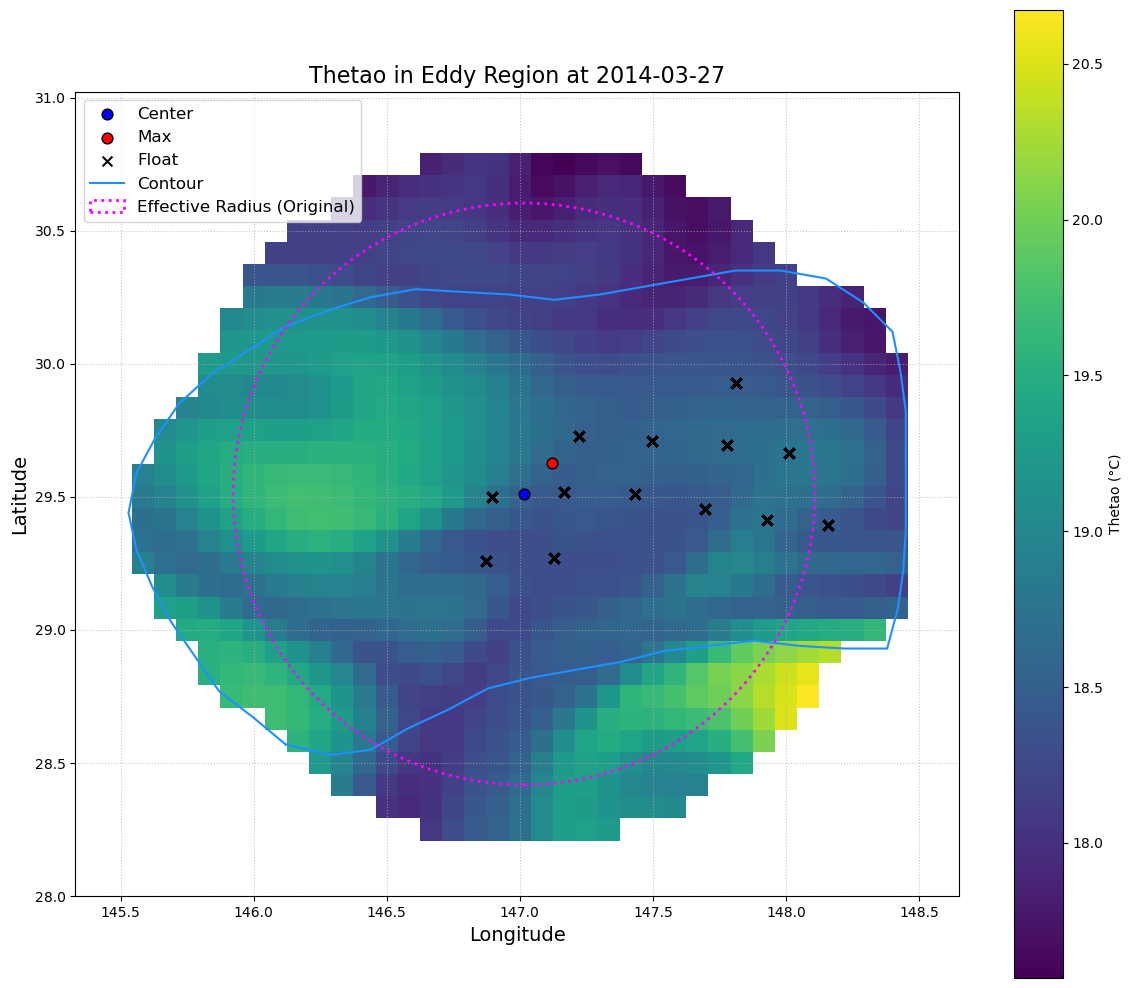

In [15]:
# --- 可视化提取结果 (修改后) ---
fig, ax = plt.subplots(figsize=(12, 10)) # 使用 ax 对象进行绘图
ax.set_aspect('equal')

# 绘制 thetao 区域
# thetao_region 的计算仍然基于 enlarged_radius_degrees (radius * 1.2)
mesh = ax.pcolormesh(lon, lat, thetao_region, shading='auto', cmap='viridis')
fig.colorbar(mesh, ax=ax, label='Thetao (°C)')

# 绘制涡旋中心和最值点
ax.scatter(test_eddy[2], test_eddy[3], label='Center', color='blue', s=60, zorder=5, edgecolors='k')
ax.scatter(test_eddy[4], test_eddy[5], label='Max', color='red', s=60, zorder=5, edgecolors='k')

# 绘制筛选后的浮标
ax.scatter(test_float_filtered['Longitude'], test_float_filtered['Latitude'],
           label='Float', color='black', marker='x', s=50, zorder=5)

# 绘制涡旋轮廓线
ax.plot(test_eddy[6], test_eddy[7], label='Contour', color='dodgerblue', linewidth=1.5)

# ---- 修改点 1: 绘制原始的有效半径圆 ----
# radius_meters 和 center_lon_eddy, center_lat_eddy, track.circle_enlargement_factor
# 以及 enlarged_radius_degrees 变量应已在之前的代码中定义。
# enlarged_radius_degrees = (radius_meters / 111320) * track.circle_enlargement_factor (用于thetao_region)
# 现在我们计算原始半径（单位：度）用于绘图
original_radius_degrees = radius_meters / 111320

original_effective_circle_patch = plt.Circle((center_lon_eddy, center_lat_eddy),
                                        original_radius_degrees, # 使用原始半径
                                        color='magenta',         # 修改颜色以区分
                                        fill=False,
                                        linestyle=':',         # 修改线型，例如点线
                                        linewidth=2,
                                        label='Effective Radius (Original)', # 更新标签
                                        zorder=4)
ax.add_patch(original_effective_circle_patch)
# -----------------------------------------

# 设置图表属性
ax.set_title(f'Thetao in Eddy Region at {test_date.strftime("%Y-%m-%d")}', fontsize=16)
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)

# 调整X, Y轴范围以更好地显示轮廓和圆
# enlarged_radius_degrees 仍然用于确定 thetao 数据的最大范围，所以 xlim/ylim 逻辑保持不变
all_lons_for_extent = np.concatenate((np.array(test_eddy[6]), [center_lon_eddy - enlarged_radius_degrees, center_lon_eddy + enlarged_radius_degrees]))
all_lats_for_extent = np.concatenate((np.array(test_eddy[7]), [center_lat_eddy - enlarged_radius_degrees, center_lat_eddy + enlarged_radius_degrees]))
ax.set_xlim([np.min(all_lons_for_extent) - 0.2, np.max(all_lons_for_extent) + 0.2])
ax.set_ylim([np.min(all_lats_for_extent) - 0.2, np.max(all_lats_for_extent) + 0.2])

# ---- 修改点 2: 指定图例位置以优化 ----
ax.legend(loc='upper left', fontsize=12) # 例如，固定在左上角
# 其他可选位置: 'upper right', 'lower left', 'lower right', 'center left', 'center right', 
# 'lower center', 'upper center', 'center'
# -----------------------------------------

ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout() # 你提到即使注释掉这行，警告依然存在。
                     # 指定 legend 的 loc 通常能解决这个特定的 UserWarning。
                     # 如果需要，可以取消注释此行，但它本身不是警告的原因。
plt.show()

# 关闭打开的NetCDF文件 (这部分代码在你的截图之外，但通常是个好习惯)
# if 'test_Glorys' in locals() and test_Glorys is not None:
#     try:
#         test_Glorys.close()
#     except Exception as e:
#         print(f"Error closing NetCDF file: {e}")

# Ray Tracing

In [2]:
with open('acs.pkl', 'rb') as f:
    acs = pickle.load(f)

with open('acl.pkl', 'rb') as f:
    acl = pickle.load(f)

with open('cs.pkl', 'rb') as f:
    cs = pickle.load(f)

with open('cl.pkl', 'rb') as f:
    cl = pickle.load(f)

/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:1197: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


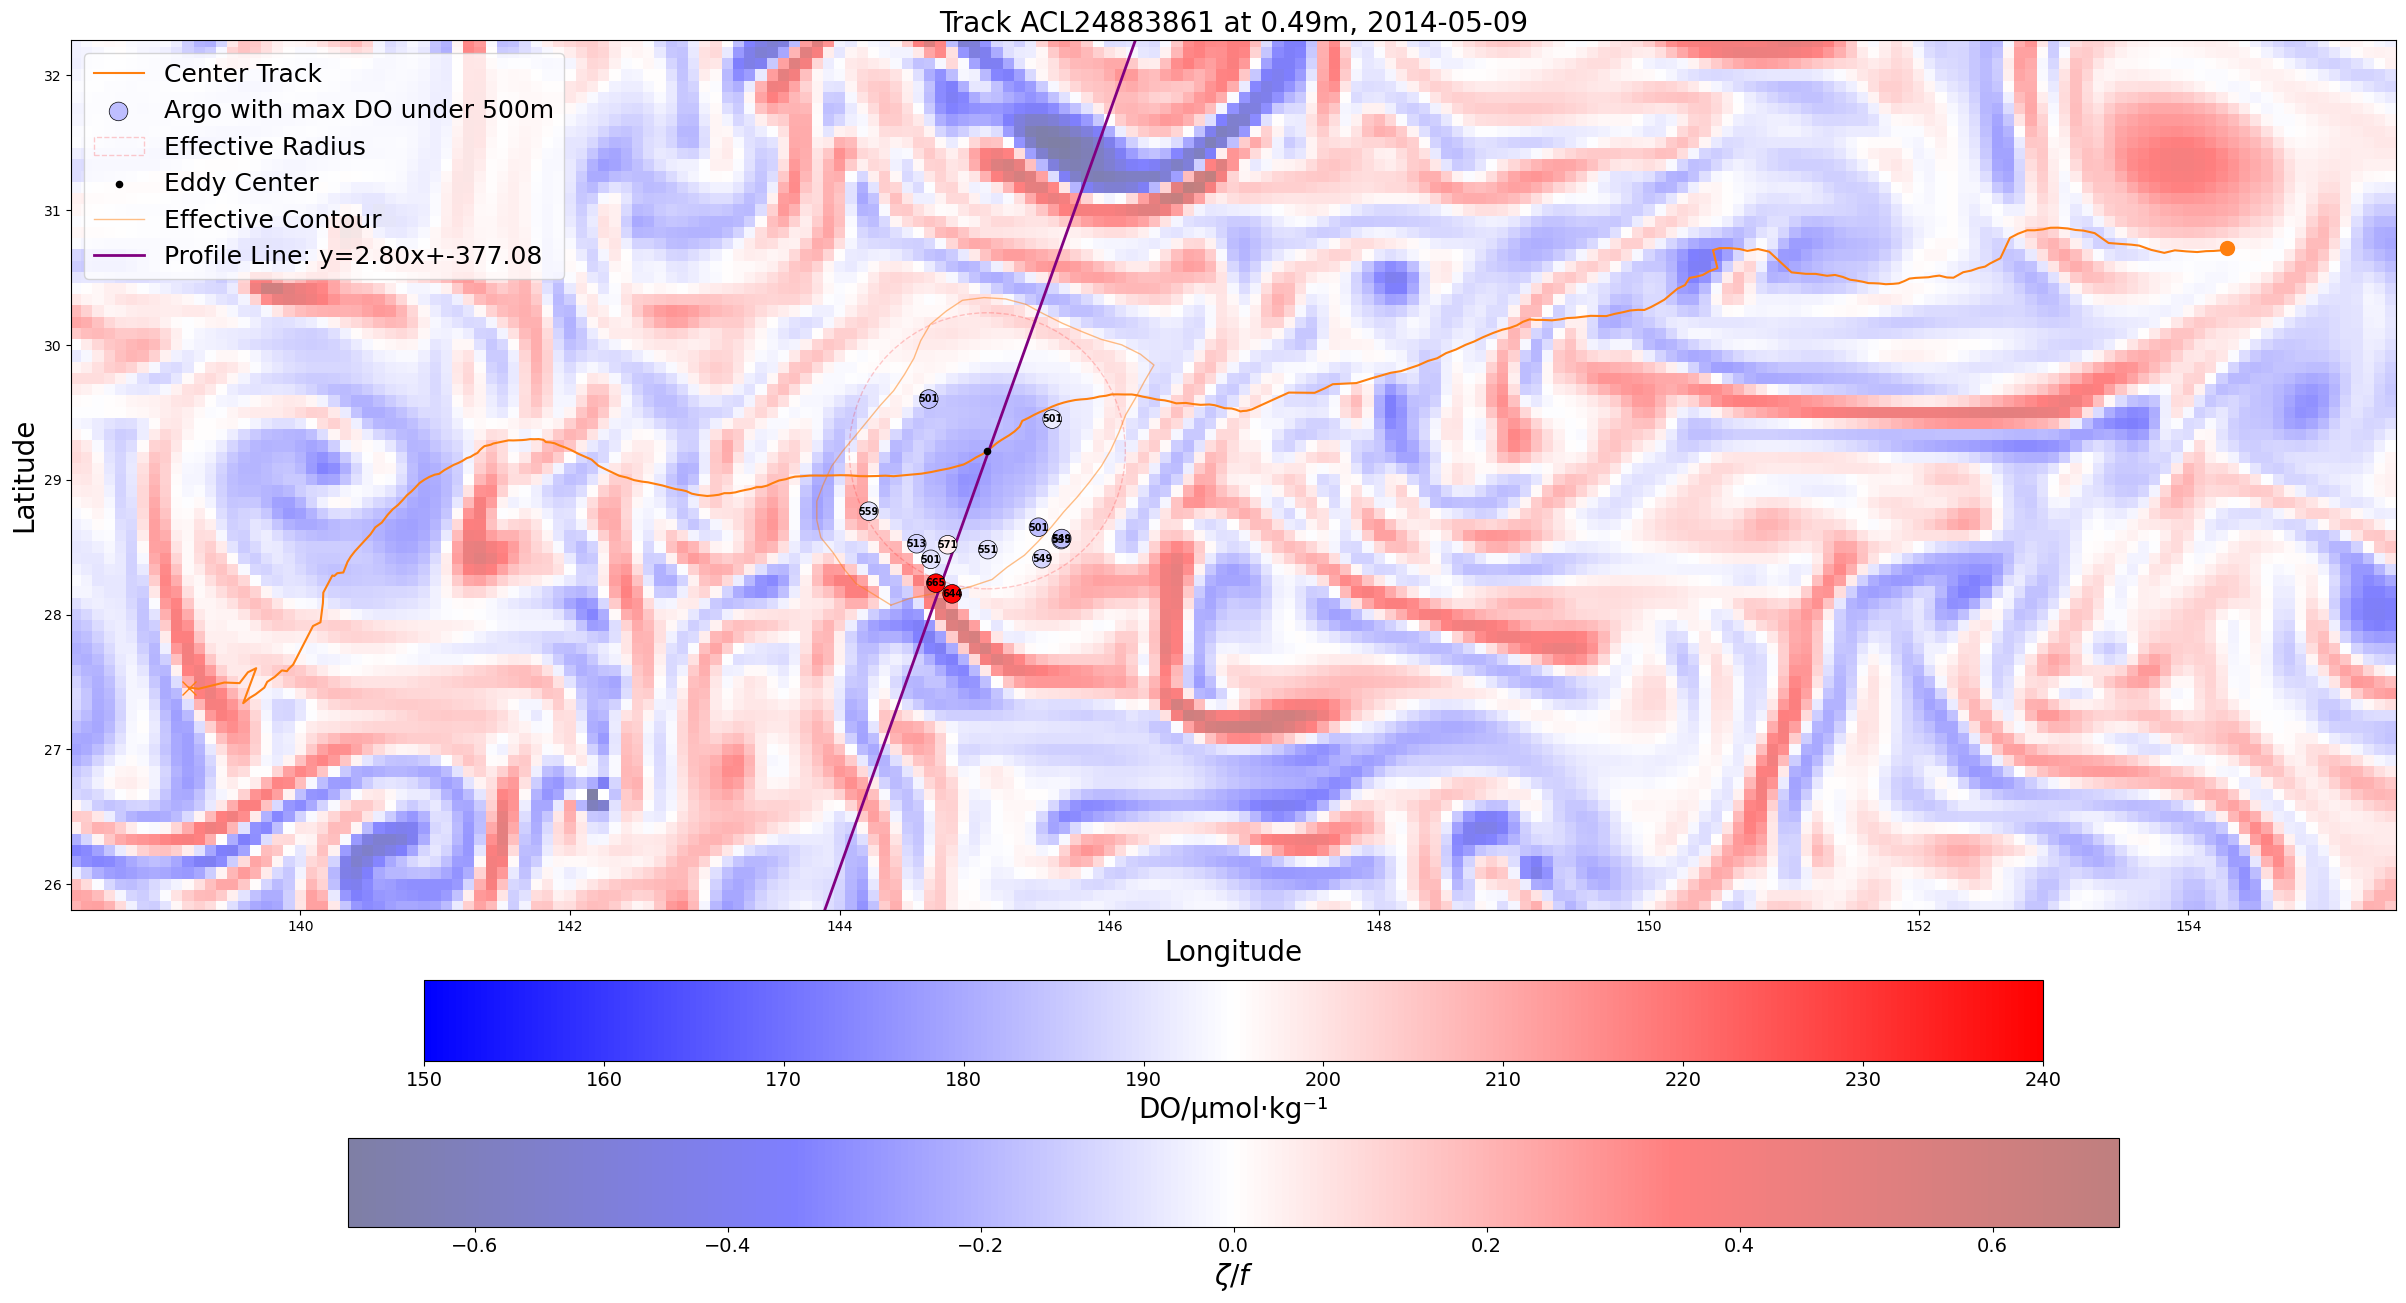

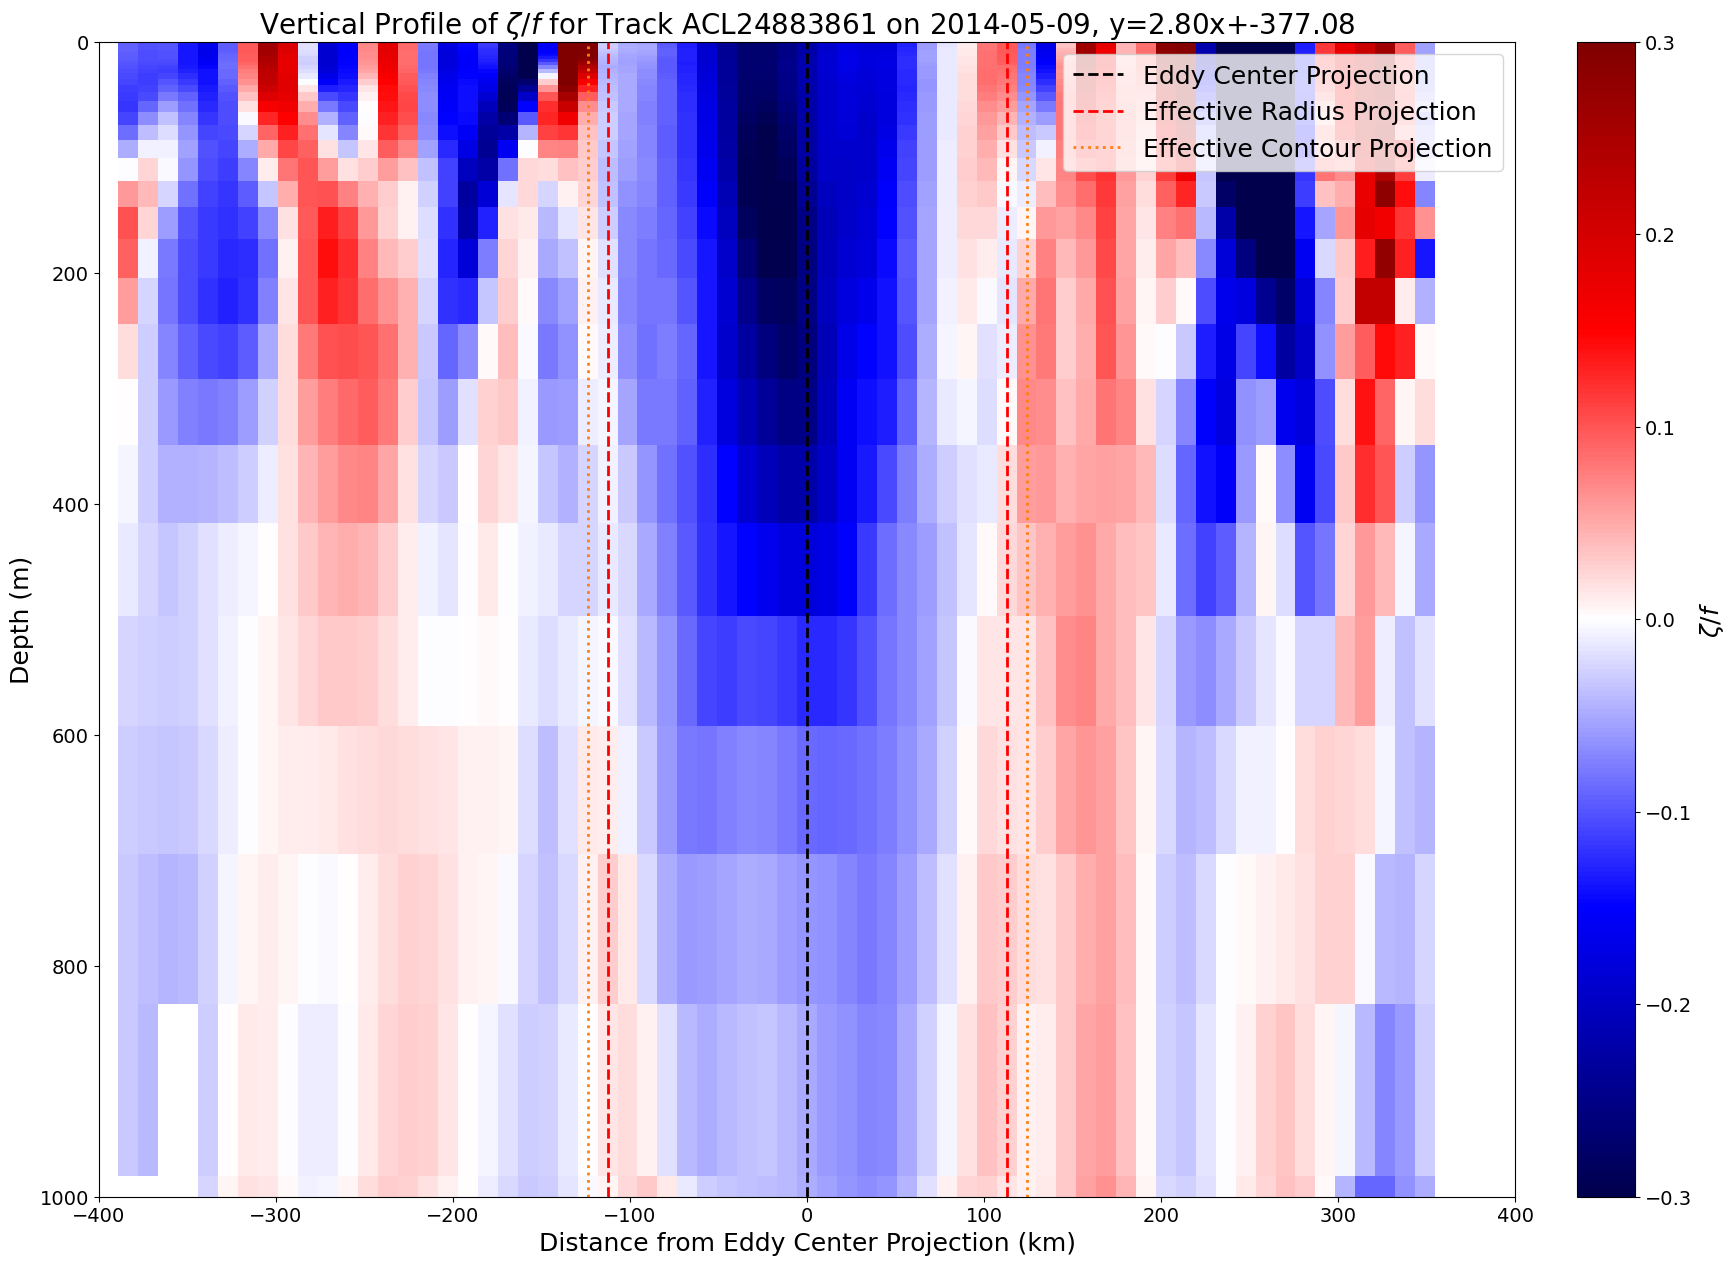

In [3]:
needed_k = 2.8
needed_b = -377.08

for needed_idx in track.get_idx(acl, 24883861, '2014-05-09', '2014-05-09'):
    track.plot_track_area_horizontal_glorys(acl, 24883861, needed_idx, show_fig=True, deep_argo=True, k=needed_k, b=needed_b)
    track.plot_vertical_glorys(acl, 24883861, needed_idx, k=needed_k, b=needed_b, show_fig=True, xmin=-400, xmax=400, ymin=0, ymax=1000)

    needed_data_package = track.get_vertical_glorys(acl, 24883861, needed_idx, k=needed_k, b=needed_b, variables=['vorticity', 'u', 'v', 'salinity', 'thetao'])

In [4]:
new_data_package = track.regrid_vertical_slice(needed_data_package,dy=4, dz=1)

In [5]:
print(needed_data_package['profile_data']['vorticity'].shape)
print(new_data_package['profile_data']['vorticity'].shape)
print(new_data_package.keys())
print(new_data_package['profile_data'].keys())
print(new_data_package['profile_data']['vorticity'].shape)
print(new_data_package['y_coords'].shape)
print(new_data_package['z_coords'].shape)
print(new_data_package['projections'])

(40, 67)
(1942, 186)
dict_keys(['profile_data', 'y_coords', 'z_coords', 'lon_coords', 'lat_coords', 'projections', 'metadata'])
dict_keys(['vorticity', 'u', 'v', 'salinity', 'thetao'])
(1942, 186)
(186,)
(1942,)
{'radius': [-112.71843954542129, 112.62423039303036], 'contour': [-123.99538564358414, 123.88139473591639]}


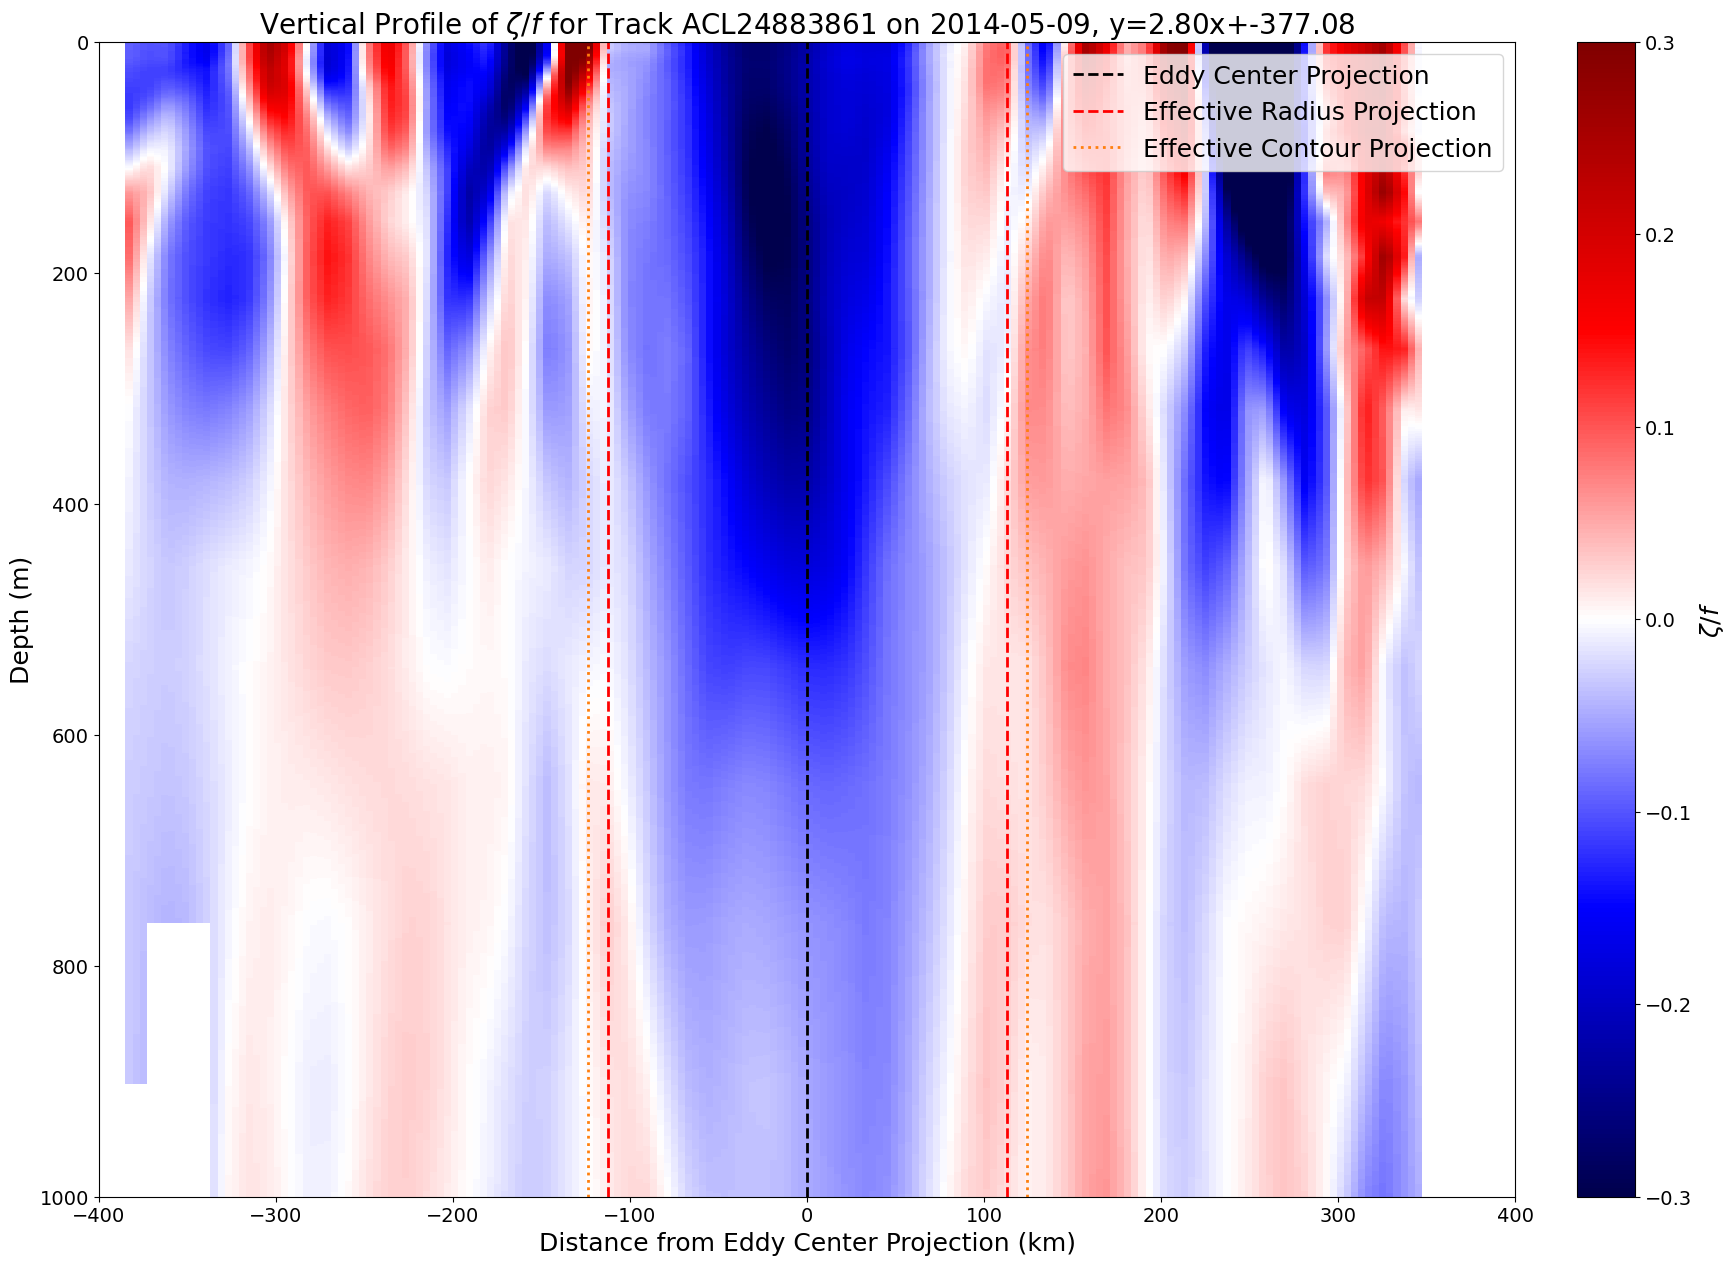

In [6]:
track.plot_data_package(new_data_package, acl, 'vorticity', show_fig=True, xmin=-400, xmax=400, ymin=0, ymax=1000)

In [7]:
R_earth = 6371e3  # 地球半径 (米)
Omega = 7.2921e-5  # 地球自转角速度 (弧度/秒)
center_lat = new_data_package['lat_coords'][np.argmin(np.abs(new_data_package['y_coords']))]

f = 2 * Omega * np.sin(np.deg2rad(center_lat))

In [8]:
raytraceR_inputs = track.get_raytraceR_inputs(new_data_package, f)


--- Data Preparation Summary for raytraceR ---
Z (Depth) meshgrid shape: (1942, 186), min/max: 0.5/1941.5 m
Y (Cross-stream) meshgrid shape: (1942, 186), min/max: -394.9/345.1 km
dz (Depth spacing): 1.000 m
dy (Cross-stream spacing): 4000.000 m
Calculated F2 shape: (1942, 186), min/max: 2.81e-09/7.52e-09
Calculated S2 shape: (1942, 186), min/max: -2.16e-06/4.72e-07
Calculated N2 shape: (1942, 186), min/max: 0.00e+00/2.40e-04
Calculated ug shape: (1942, 186), min/max: -9.05e-01/5.73e-01
Calculated bg shape: (1942, 186), min/max: -2.59e-02/1.28e-02
Calculated omegamin shape: (1942, 186), min/max: 0.00e+00/8.67e-05
Coriolis frequency (f): 7.1210e-05 rad/s
Wave frequency (omega): 6.9073e-05 rad/s
--------------------------------------------



In [9]:
scipy.io.savemat('GLORYS_raytraceR_inputs.mat', raytraceR_inputs)